# ODI Complaints Cleaning

This notebook is where we use the EDA findings to create cleaning decisions for the complaints data. The work is kept layered and inspectable so we can see what changes, why it changes, and how it affects the first modeling tables.

## 1. Setup And Ground Rules

Importing the basic tooling and making the notebook display rules explicit.

In [2]:
# Imports
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

# Preferred pandas and seaborn display parameters
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)
pd.set_option('display.max_colwidth', 120)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')

## 2. Load The Working Dataset

Load the combined processed complaints file that came out of initial setup.

In [3]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data' / 'processed').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

COMBINED_PATH = PROJECT_ROOT / 'data' / 'processed' / 'odi_complaints_combined.parquet'

raw_df = pd.read_parquet(COMBINED_PATH)
raw_df = raw_df.drop(columns=['source_zip', 'source_file'], errors='ignore')

print("Loaded:", COMBINED_PATH.name)
print("Shape:", raw_df.shape)

Loaded: odi_complaints_combined.parquet
Shape: (545231, 49)


## 3. Source Data Notes

Before changing anything, pull in the parts of `CMPL.txt` with useful info for cleaning to keep our work consistent with the source documentation.

In [4]:
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.schema_checks import get_schema_spec

spec = get_schema_spec('complaints')
schema_df = pd.DataFrame(spec['fields'])
desc_map = schema_df.set_index('name')['description'].to_dict()

focus_cols = [
    'yeartxt', 'faildate', 'datea', 'ldate', 'miles', 'injured', 'deaths',
    'veh_speed', 'vin', 'purch_dt', 'manuf_dt', 'state', 'dealer_state',
    'prod_type', 'cdescr'
]

schema_view = schema_df.loc[
    schema_df['name'].isin(focus_cols),
    ['name', 'type', 'size', 'description']
].sort_values('name')

change_notes = pd.DataFrame([
    {'note': 'May-Jun 2021 file update', 'implication': 'Previously blank Y/N fields may now appear as N'},
    {'note': 'May-Jun 2021 file update', 'implication': 'Previously blank numeric fields may now appear as 0'},
    {'note': 'May-Jun 2021 file update', 'implication': 'Manufacturer, make, model, and component values may reflect newer cleanup over time'}
])

print("Schema overview of major features:")
display(schema_view)

print("\nDocumented schema changes:")
display(change_notes)

Schema overview of major features:


,name,type,size,description
19,cdescr,CHAR,2048,DESCRIPTION OF THE COMPLAINT
15,datea,CHAR,8,DATE ADDED TO FILE (YYYYMMDD)
43,dealer_state,CHAR,2,DEALER'S STATE CODE
10,deaths,NUMBER,2,NUMBER OF FATALITIES
7,faildate,CHAR,8,DATE OF INCIDENT (YYYYMMDD)
9,injured,NUMBER,2,NUMBER OF PERSONS INJURED
16,ldate,CHAR,8,DATE COMPLAINT RECEIVED BY NHTSA (YYYYMMDD)
37,manuf_dt,CHAR,8,DATE OF MANUFACTURE (YYYYMMDD)
17,miles,NUMBER,7,VEHICLE MILEAGE AT FAILURE
45,prod_type,CHAR,4,PRODUCT TYPE CODE: V =VEHICLE T =TIRES E =EQUIPMENT C =CHILD RESTRAINT



Documented schema changes:


,note,implication
0,May-Jun 2021 file update,Previously blank Y/N fields may now appear as N
1,May-Jun 2021 file update,Previously blank numeric fields may now appear as 0
2,May-Jun 2021 file update,"Manufacturer, make, model, and component values may reflect newer cleanup over time"


## 4. Modeling Context

We have three different models for our project tasks with different requirements, so we need to have both a general cleaned baseline to explore as well as targeted preprocessing per model.

In [5]:
model_plan = pd.DataFrame([
    {
        'model': 'severity ranking model',
        'unit_of_analysis': 'complaint case keyed by odino',
        'time_anchor': 'ldate',
        'initial_cohort': "prod_type == 'V'",
        'target_or_output': 'primary high-risk flag from deaths, injured, fire, and crash',
        'baseline': 'logistic regression',
        'strong_candidate': 'CatBoostClassifier'
    },
    {
        'model': 'component category model',
        'unit_of_analysis': 'complaint-component row',
        'time_anchor': 'ldate',
        'initial_cohort': "prod_type == 'V'",
        'target_or_output': 'cleaned component group built from compdesc',
        'baseline': 'multinomial logistic regression',
        'strong_candidate': 'CatBoostClassifier'
    },
    {
        'model': 'NLP early warning watchlist',
        'unit_of_analysis': 'cohort/topic/component month',
        'time_anchor': 'ldate',
        'initial_cohort': "prod_type == 'V'",
        'target_or_output': 'monthly watchlist ranked by topic growth and complaint activity',
        'baseline': 'trend and spike rules',
        'strong_candidate': 'topic growth plus cohort monitoring'
    }
])

display(model_plan)

,model,unit_of_analysis,time_anchor,initial_cohort,target_or_output,baseline,strong_candidate
0,severity ranking model,complaint case keyed by odino,ldate,prod_type == 'V',"primary high-risk flag from deaths, injured, fire, and crash",logistic regression,CatBoostClassifier
1,component category model,complaint-component row,ldate,prod_type == 'V',cleaned component group built from compdesc,multinomial logistic regression,CatBoostClassifier
2,NLP early warning watchlist,cohort/topic/component month,ldate,prod_type == 'V',monthly watchlist ranked by topic growth and complaint activity,trend and spike rules,topic growth plus cohort monitoring


### 4.1 Vehicle Cohort Check

Confirm whether the vehicle cohort is large enough to justify a vehicle-only cleaning and modeling path. There was large missingness in the data that was really structural based on product type, so this should hopefully gives us a good baseline.

In [6]:
prod_counts = raw_df['prod_type'].astype('string').value_counts(dropna=False).rename_axis('prod_type').reset_index(name='row_count')
prod_counts['row_pct'] = (prod_counts['row_count'] / len(raw_df) * 100).round(2)

vehicle_mask = raw_df['prod_type'].astype('string') == 'V'
vehicle_df = raw_df.loc[vehicle_mask].copy()

cohort_summary = pd.DataFrame([
    {
        'view': 'all rows',
        'rows': len(raw_df),
        'row_pct': 100.0,
        'unique_makes': raw_df['maketxt'].nunique(dropna=True),
        'unique_models': raw_df['modeltxt'].nunique(dropna=True),
        'fire_y_pct': round(float((raw_df['fire'].astype('string') == 'Y').mean() * 100), 2),
        'narrative_non_null_pct': round(float(raw_df['cdescr'].notna().mean() * 100), 2)
    },
    {
        'view': "prod_type='V'",
        'rows': len(vehicle_df),
        'row_pct': round(float(len(vehicle_df) / len(raw_df) * 100), 2),
        'unique_makes': vehicle_df['maketxt'].nunique(dropna=True),
        'unique_models': vehicle_df['modeltxt'].nunique(dropna=True),
        'fire_y_pct': round(float((vehicle_df['fire'].astype('string') == 'Y').mean() * 100), 2),
        'narrative_non_null_pct': round(float(vehicle_df['cdescr'].notna().mean() * 100), 2)
    }
])

core_cols = ['maketxt', 'modeltxt', 'yeartxt', 'state', 'miles', 'veh_speed', 'cdescr', 'fire', 'crash']
core_avail = pd.DataFrame({
    'all_rows_non_null_pct': (raw_df[core_cols].notna().mean() * 100).round(2),
    'vehicle_only_non_null_pct': (vehicle_df[core_cols].notna().mean() * 100).round(2)
}).reset_index().rename(columns={'index': 'column'})

print("Dataset product type makeup:")
display(prod_counts)

print("\nSummary of vehicle cohort vs full dataset:")
display(cohort_summary)

print("\nCoverage of major features in vehicle cohort vs full dataset: ")
display(core_avail)

Dataset product type makeup:


,prod_type,row_count,row_pct
0,V,537936,98.66
1,T,3820,0.7
2,E,2142,0.39
3,C,1326,0.24
4,<NA>,7,0.0



Summary of vehicle cohort vs full dataset:


,view,rows,row_pct,unique_makes,unique_models,fire_y_pct,narrative_non_null_pct
0,all rows,545231,100.00,811,3856,1.82,99.99
1,prod_type='V',537936,98.66,398,2718,1.82,99.99



Coverage of major features in vehicle cohort vs full dataset: 


,column,all_rows_non_null_pct,vehicle_only_non_null_pct
0,maketxt,100.00,100.00
1,modeltxt,100.00,100.00
2,yeartxt,100.00,100.00
3,state,100.00,100.00
4,miles,31.22,31.64
5,veh_speed,54.68,55.42
6,cdescr,99.99,99.99
7,fire,100.00,100.00
8,crash,100.00,100.00


### 4.2 Field Decision Matrix

Working decision table for the most important columns, explicitly define each field's meaning, issue pattern, and likely handling before we change anything.

In [7]:
field_decisions = pd.DataFrame([
    {
        'field': 'cmplid',
        'schema_note': desc_map['cmplid'],
        'base_clean': 'keep as unique row key',
        'severity_model': 'not the case key',
        'component_model': 'row key only',
        'nlp_watchlist': 'not a feature',
        'current_call': 'settled',
        'note': ''
    },
    {
        'field': 'odino',
        'schema_note': desc_map['odino'],
        'base_clean': 'keep as complaint-case reference',
        'severity_model': 'case key',
        'component_model': 'reference only',
        'nlp_watchlist': 'case reference only',
        'current_call': 'settled',
        'note': ''
    },
    {
        'field': 'prod_type',
        'schema_note': desc_map['prod_type'],
        'base_clean': 'strip, uppercase, validate',
        'severity_model': 'start with V only',
        'component_model': 'start with V only',
        'nlp_watchlist': 'start with V only',
        'current_call': 'settled',
        'note': ''
    },
    {
        'field': 'maketxt',
        'schema_note': desc_map['maketxt'],
        'base_clean': 'strip and uppercase',
        'severity_model': 'baseline feature',
        'component_model': 'baseline feature',
        'nlp_watchlist': 'cohort field',
        'current_call': 'settled',
        'note': ''
    },
    {
        'field': 'modeltxt',
        'schema_note': desc_map['modeltxt'],
        'base_clean': 'strip and uppercase',
        'severity_model': 'baseline feature',
        'component_model': 'baseline feature',
        'nlp_watchlist': 'cohort field',
        'current_call': 'settled',
        'note': 'Make-aware cleanup may still help later'
    },
    {
        'field': 'compdesc',
        'schema_note': desc_map.get('compdesc', 'COMPONENT DESCRIPTION'),
        'base_clean': 'strip and uppercase',
        'severity_model': 'exclude from first baseline',
        'component_model': 'target source for cleaned component group',
        'nlp_watchlist': 'component bucket after grouping',
        'current_call': 'mostly settled',
        'note': 'Need a cleaned component grouping pass next'
    },
    {
        'field': 'yeartxt',
        'schema_note': desc_map['yeartxt'],
        'base_clean': 'convert to Int64 and null unknown',
        'severity_model': 'baseline feature',
        'component_model': 'baseline feature',
        'nlp_watchlist': 'cohort field',
        'current_call': 'settled',
        'note': 'Keep unknown-year flag'
    },
    {
        'field': 'ldate',
        'schema_note': desc_map['ldate'],
        'base_clean': 'preserve raw datetime',
        'severity_model': 'main time anchor',
        'component_model': 'main time anchor',
        'nlp_watchlist': 'main time anchor',
        'current_call': 'settled',
        'note': ''
    },
    {
        'field': 'faildate',
        'schema_note': desc_map['faildate'],
        'base_clean': 'preserve raw datetime and add trust flag',
        'severity_model': 'use only through safe derived lag features',
        'component_model': 'optional metadata',
        'nlp_watchlist': 'only if trusted',
        'current_call': 'settled',
        'note': "Trusted only when faildate <= ldate and fail_year >= model_year - 1"
    },
    {
        'field': 'datea',
        'schema_note': desc_map['datea'],
        'base_clean': 'preserve raw datetime',
        'severity_model': 'exclude from first baseline',
        'component_model': 'exclude from first baseline',
        'nlp_watchlist': 'exclude from first pass',
        'current_call': 'settled',
        'note': 'Keep for audit only'
    },
    {
        'field': 'miles',
        'schema_note': desc_map['miles'],
        'base_clean': 'convert to Int64, keep zero, flag highs',
        'severity_model': 'baseline feature plus missing flag',
        'component_model': 'baseline feature plus missing flag',
        'nlp_watchlist': 'cohort metadata',
        'current_call': 'settled',
        'note': 'No zero flag in v1'
    },
    {
        'field': 'veh_speed',
        'schema_note': desc_map['veh_speed'],
        'base_clean': 'convert to Int64, null 999, keep zero, flag highs',
        'severity_model': 'baseline feature plus missing flag',
        'component_model': 'baseline feature plus missing flag',
        'nlp_watchlist': 'cohort metadata',
        'current_call': 'settled',
        'note': 'No zero flag in v1 and >200 stays flagged'
    },
    {
        'field': 'state',
        'schema_note': desc_map['state'],
        'base_clean': 'strip, uppercase, validate',
        'severity_model': 'baseline feature',
        'component_model': 'baseline feature',
        'nlp_watchlist': 'regional cohort field',
        'current_call': 'settled',
        'note': ''
    },
    {
        'field': 'injured',
        'schema_note': desc_map['injured'],
        'base_clean': 'convert to Int64 and keep zero',
        'severity_model': 'label only, not a feature',
        'component_model': 'exclude from first baseline',
        'nlp_watchlist': 'severity summary later',
        'current_call': 'settled',
        'note': 'Primary severity label input'
    },
    {
        'field': 'deaths',
        'schema_note': desc_map['deaths'],
        'base_clean': 'convert to Int64 and keep zero',
        'severity_model': 'label only, not a feature',
        'component_model': 'exclude from first baseline',
        'nlp_watchlist': 'severity summary later',
        'current_call': 'settled',
        'note': 'Primary severity label input'
    },
    {
        'field': 'fire / crash',
        'schema_note': 'Y/N severity indicators',
        'base_clean': 'strip and uppercase',
        'severity_model': 'label only, not a feature',
        'component_model': 'exclude from first baseline',
        'nlp_watchlist': 'watchlist outcome signals',
        'current_call': 'settled',
        'note': 'Primary severity label input'
    },
    {
        'field': 'medical_attn / vehicles_towed_yn',
        'schema_note': 'Y/N severity-adjacent indicators',
        'base_clean': 'strip and uppercase',
        'severity_model': 'sensitivity label only',
        'component_model': 'exclude from first baseline',
        'nlp_watchlist': 'possible severity context later',
        'current_call': 'settled',
        'note': 'Not part of the primary severity label'
    },
    {
        'field': 'cdescr',
        'schema_note': desc_map['cdescr'],
        'base_clean': 'strip only',
        'severity_model': 'exclude from first structured baseline',
        'component_model': 'exclude from first structured baseline',
        'nlp_watchlist': 'main input field',
        'current_call': 'settled',
        'note': 'Real text prep stays in the NLP track'
    }
])

display(field_decisions)

,field,schema_note,base_clean,severity_model,component_model,nlp_watchlist,current_call,note
0,cmplid,"NHTSA'S INTERNAL UNIQUE SEQUENCE NUMBER. IS AN UPDATEABLE FIELD,THUS DATA FOR A GIVEN RECORD POTENTIALLY COULD CHANG...",keep as unique row key,not the case key,row key only,not a feature,settled,
1,odino,"NHTSA'S INTERNAL REFERENCE NUMBER. THIS NUMBER MAY BE REPEATED FOR MULTIPLE COMPONENTS. ALSO, IF LDATE IS PRIOR TO D...",keep as complaint-case reference,case key,reference only,case reference only,settled,
2,prod_type,PRODUCT TYPE CODE: V =VEHICLE T =TIRES E =EQUIPMENT C =CHILD RESTRAINT,"strip, uppercase, validate",start with V only,start with V only,start with V only,settled,
3,maketxt,VEHICLE/EQUIPMENT MAKE,strip and uppercase,baseline feature,baseline feature,cohort field,settled,
4,modeltxt,VEHICLE/EQUIPMENT MODEL,strip and uppercase,baseline feature,baseline feature,cohort field,settled,Make-aware cleanup may still help later
5,compdesc,SPECIFIC COMPONENT'S DESCRIPTION,strip and uppercase,exclude from first baseline,target source for cleaned component group,component bucket after grouping,mostly settled,Need a cleaned component grouping pass next
6,yeartxt,"MODEL YEAR, 9999 IF UNKNOWN or N/A",convert to Int64 and null unknown,baseline feature,baseline feature,cohort field,settled,Keep unknown-year flag
7,ldate,DATE COMPLAINT RECEIVED BY NHTSA (YYYYMMDD),preserve raw datetime,main time anchor,main time anchor,main time anchor,settled,
8,faildate,DATE OF INCIDENT (YYYYMMDD),preserve raw datetime and add trust flag,use only through safe derived lag features,optional metadata,only if trusted,settled,Trusted only when faildate <= ldate and fail_year >= model_year - 1
9,datea,DATE ADDED TO FILE (YYYYMMDD),preserve raw datetime,exclude from first baseline,exclude from first baseline,exclude from first pass,settled,Keep for audit only


## 5. Layered Cleaning Frames

The notebook is set up around layered data frames (the standardized frame, the boolean flags frame, and candidate features frame) rather than one destructive cleaning pass. This section goes over them as a whole with the constants and helpers needed defined here.

In [ ]:
std_df = raw_df.copy()
flag_df = pd.DataFrame(index=raw_df.index)
candidate_df = None

YN_COLS = [
    'crash',
    'fire',
    'police_rpt_yn',
    'orig_owner_yn',
    'anti_brakes_yn',
    'cruise_cont_yn',
    'orig_equip_yn',
    'repaired_yn',
    'medical_attn',
    'vehicles_towed_yn'
]

UPPER_COLS = [
    'mfr_name',
    'maketxt',
    'modeltxt',
    'compdesc',
    'city',
    'state',
    'vin',
    'cmpl_type',
    'dealer_name',
    'dealer_city',
    'dealer_state',
    'prod_type'
] + YN_COLS

STRIP_ONLY_COLS = [
    'cdescr',
    'fuel_sys',
    'fuel_type',
    'trans_type',
    'drive_train',
    'dot',
    'tire_size',
    'loc_of_tire',
    'tire_fail_type',
    'dealer_zip',
    'dealer_tel'
]

INT_COLS = [
    'yeartxt',
    'injured',
    'deaths',
    'miles',
    'occurences',
    'num_cyls',
    'veh_speed'
]

DATE_STR_COLS = [
    'purch_dt',
    'manuf_dt'
]

VALID_PROD_TYPES = {
    'V',
    'T',
    'E',
    'C'
}

POSTAL_CODES = {
    'AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'FL', 'GA', 'HI', 'ID', 'IL',
    'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD', 'MA', 'MI', 'MN', 'MS', 'MO', 'MT',
    'NE', 'NV', 'NH', 'NJ', 'NM', 'NY', 'NC', 'ND', 'OH', 'OK', 'OR', 'PA', 'RI',
    'SC', 'SD', 'TN', 'TX', 'UT', 'VT', 'VA', 'WA', 'WV', 'WI', 'WY', 'DC', 'PR',
    'VI', 'GU', 'AS', 'MP', 'FM', 'MH', 'PW', 'AE', 'AA', 'AP'
}

MISS_TAG = '__MISSING__'

# -----------------------------------------------------------------------------
# Small cleaning helpers
# -----------------------------------------------------------------------------
def strip_text(series):
    text = series.astype('string').str.strip()
    return text.replace({'': pd.NA})


def upper_text(series):
    return strip_text(series).str.upper()


def to_int(series):
    return pd.to_numeric(strip_text(series), errors='coerce').astype('Int64')


def to_dt(series):
    return pd.to_datetime(strip_text(series), format='%Y%m%d', errors='coerce')


def compare_view(mask, cols, n=10):
    raw_view = raw_df.loc[mask, cols].add_prefix('raw_')
    std_view = std_df.loc[mask, cols].add_prefix('std_')
    cand_view = candidate_df.loc[mask, cols].add_prefix('cand_')
    return raw_view.join(std_view).join(cand_view).head(n)

### 5.1 Base Standardization

Handles the safest shared standardization work first by normalizing types and formatting, saving more target changes for later.

In [9]:
text_rows = []
dtype_rows = []

# Format to uppercase and change dtype of all UPPER_COL features
for col in UPPER_COLS:
    if col not in std_df.columns:
        continue
    before = std_df[col].copy()
    std_df[col] = upper_text(std_df[col])
    changed = int(
        before.astype('string')
        .fillna(MISS_TAG)
        .ne(std_df[col].astype('string').fillna(MISS_TAG))
        .sum()
    )
    text_rows.append(
        {
            'column': col,
            'action': 'strip + upper',
            'changed_rows': changed,
            'null_after': int(std_df[col].isna().sum()),
        }
    )

# Strip whitespace and format all listed features
for col in STRIP_ONLY_COLS:
    if col not in std_df.columns:
        continue
    before = std_df[col].copy()
    std_df[col] = strip_text(std_df[col])
    changed = int(
        before.astype('string')
        .fillna(MISS_TAG)
        .ne(std_df[col].astype('string').fillna(MISS_TAG))
        .sum()
    )
    text_rows.append(
        {
            'column': col,
            'action': 'strip only',
            'changed_rows': changed,
            'null_after': int(std_df[col].isna().sum()),
        }
    )

# Change all columns that should be int
for col in INT_COLS:
    if col not in std_df.columns:
        continue
    before_dtype = str(std_df[col].dtype)
    before_non_null = int(std_df[col].notna().sum())
    std_df[col] = to_int(std_df[col])
    dtype_rows.append(
        {
            'column': col,
            'action': 'to Int64',
            'dtype_before': before_dtype,
            'dtype_after': str(std_df[col].dtype),
            'non_null_before': before_non_null,
            'non_null_after': int(std_df[col].notna().sum()),
        }
    )

# Format data columns as proper datetimes
for col in DATE_STR_COLS:
    if col not in std_df.columns:
        continue
    before_dtype = str(std_df[col].dtype)
    before_non_null = int(std_df[col].notna().sum())
    std_df[col] = to_dt(std_df[col])
    dtype_rows.append(
        {
            'column': col,
            'action': 'to datetime',
            'dtype_before': before_dtype,
            'dtype_after': str(std_df[col].dtype),
            'non_null_before': before_non_null,
            'non_null_after': int(std_df[col].notna().sum()),
        }
    )

text_log = pd.DataFrame(text_rows).sort_values(
    ['changed_rows', 'column'], ascending=[False, True]
)
dtype_log = pd.DataFrame(dtype_rows)

print("Changes from text actions: ")
display(text_log[text_log['changed_rows'] > 0])

print("\nChanges from data type changes: ")
display(dtype_log)

Changes from text actions: 


,column,action,changed_rows,null_after
0,mfr_name,strip + upper,542591,7
4,city,strip + upper,405240,28
8,dealer_name,strip + upper,48319,493790
9,dealer_city,strip + upper,46161,496796
6,vin,strip + upper,3648,11916
3,compdesc,strip + upper,1534,2
2,modeltxt,strip + upper,1242,7
1,maketxt,strip + upper,2,7



Changes from data type changes: 


,column,action,dtype_before,dtype_after,non_null_before,non_null_after
0,yeartxt,to Int64,string,Int64,545224,545224
1,injured,to Int64,string,Int64,545231,545231
2,deaths,to Int64,string,Int64,545231,545231
3,miles,to Int64,string,Int64,170200,170200
4,occurences,to Int64,string,Int64,14104,14104
5,num_cyls,to Int64,string,Int64,26763,26763
6,veh_speed,to Int64,string,Int64,298129,298129
7,purch_dt,to datetime,string,datetime64[us],2815,2815
8,manuf_dt,to datetime,string,datetime64[us],908,908


### 5.2 Issue Flags

Creates flags for values and patterns that are potentially suspicious so they can be review closer. That way we aren't potentially deleting or overwriting real values.

In [10]:
current_year = pd.Timestamp.today().year
fail_year = std_df['faildate'].dt.year
known_model_year = std_df['yeartxt'].notna() & std_df['yeartxt'].ne(9999)

flag_df['flag_prod_type_bad'] = std_df['prod_type'].notna() & ~std_df['prod_type'].isin(VALID_PROD_TYPES)
flag_df['flag_year_unknown'] = std_df['yeartxt'].eq(9999)
flag_df['flag_year_out_of_range'] = std_df['yeartxt'].notna() & ~std_df['yeartxt'].between(1900, current_year + 1)
flag_df['flag_speed_999'] = std_df['veh_speed'].eq(999)
flag_df['flag_speed_high'] = std_df['veh_speed'].gt(200) & ~std_df['veh_speed'].eq(999)
flag_df['flag_miles_high'] = std_df['miles'].gt(500000)
flag_df['flag_injured_99'] = std_df['injured'].eq(99)
flag_df['flag_deaths_99'] = std_df['deaths'].eq(99)
flag_df['flag_state_bad'] = std_df['state'].notna() & ~std_df['state'].isin(POSTAL_CODES)
flag_df['flag_dealer_state_bad'] = std_df['dealer_state'].notna() & ~std_df['dealer_state'].isin(POSTAL_CODES)
flag_df['flag_vin_len_bad'] = std_df['vin'].notna() & std_df['vin'].str.len().ne(11)
flag_df['flag_fail_after_added'] = std_df['faildate'].notna() & std_df['datea'].notna() & (std_df['faildate'] > std_df['datea'])
flag_df['flag_fail_after_received'] = std_df['faildate'].notna() & std_df['ldate'].notna() & (std_df['faildate'] > std_df['ldate'])
flag_df['flag_added_before_received'] = std_df['datea'].notna() & std_df['ldate'].notna() & (std_df['datea'] < std_df['ldate'])
flag_df['flag_date_order_bad'] = flag_df[['flag_fail_after_added', 'flag_fail_after_received', 'flag_added_before_received']].any(axis=1)
flag_df['flag_fail_old_new_vehicle'] = fail_year.notna() & known_model_year & std_df['yeartxt'].ge(1990) & fail_year.lt(1990)
flag_df['flag_fail_pre_model'] = fail_year.notna() & known_model_year & fail_year.lt(std_df['yeartxt'] - 1)
flag_df['flag_fail_pre_model_far'] = fail_year.notna() & known_model_year & fail_year.lt(std_df['yeartxt'] - 5)

flag_summary = pd.DataFrame([
    {
        'flag': col,
        'row_count': int(flag_df[col].fillna(False).sum())
    }
    for col in flag_df.columns
])
flag_summary['row_pct'] = (flag_summary['row_count'] / len(std_df) * 100).round(4)
flag_summary = flag_summary.sort_values(['row_count', 'flag'], ascending=[False, True])

display(flag_summary)

,flag,row_count,row_pct
2,flag_year_out_of_range,7708,1.4137
1,flag_year_unknown,7708,1.4137
16,flag_fail_pre_model,876,0.1607
17,flag_fail_pre_model_far,742,0.1361
15,flag_fail_old_new_vehicle,479,0.0879
5,flag_miles_high,348,0.0638
10,flag_vin_len_bad,327,0.0600
4,flag_speed_high,304,0.0558
8,flag_state_bad,47,0.0086
3,flag_speed_999,19,0.0035


### 5.3 2021 Changelog Watch

The way certain complaint fields were formatted changed around 2021, especially for blank versus `0` and blank versus `N` behavior. We need to first check if there's a clear difference between the rates across years so we don't mistakenly consider automatic defaults for real values.

In [11]:
zero_watch = (
    std_df.assign(received_year=std_df['ldate'].dt.year)
    .groupby('received_year')[['injured', 'deaths', 'miles', 'veh_speed']]
    .agg(lambda s: round(float((s == 0).mean() * 100), 2))
    .reset_index()
)

yn_watch = (
    std_df.assign(received_year=std_df['ldate'].dt.year)
    .groupby('received_year')[['crash', 'fire']]
    .agg(lambda s: round(float((s == 'N').mean() * 100), 2))
    .reset_index()
)

print("Percent of rows equal to zero by received year")
display(zero_watch)

print("Percent of rows equal to N by received year")
display(yn_watch)

Percent of rows equal to zero by received year


,received_year,injured,deaths,miles,veh_speed
0,2020,96.99,99.88,1.81,25.66
1,2021,97.03,99.89,2.67,24.3
2,2022,97.24,99.9,5.12,18.97
3,2023,97.13,99.89,5.06,19.46
4,2024,97.85,99.94,5.04,19.44
5,2025,97.73,99.93,2.9,18.39
6,2026,97.43,99.91,2.9,18.94


Percent of rows equal to N by received year


,received_year,crash,fire
0,2020,95.14,97.83
1,2021,95.1,97.58
2,2022,95.37,98.08
3,2023,95.35,98.26
4,2024,96.05,98.5
5,2025,95.84,98.51
6,2026,94.96,98.47


## 6. Focused Review Of Open Issues

This full section is a more in-depth review of flags that still need final judgement rather than just blindly generalizing cleaning. The top level is a quick overview of the main issues.

In [12]:
vehicle_mask = std_df['prod_type'].eq('V').fillna(False)
vehicle_std = std_df.loc[vehicle_mask].copy()
vehicle_flags = flag_df.loc[vehicle_mask].copy()
vehicle_std['lag_days'] = (vehicle_std['ldate'] - vehicle_std['faildate']).dt.days

open_review = pd.DataFrame([
    {
        'topic': 'negative incident-to-receipt lag',
        'rows': int(vehicle_std['lag_days'].lt(0).sum()),
        'row_pct': round(float(vehicle_std['lag_days'].lt(0).sum() / len(vehicle_std) * 100), 4),
        'current_read': 'rare and likely administrative'
    },
    {
        'topic': 'fail year < 1990 for a 1990+ vehicle',
        'rows': int(vehicle_flags['flag_fail_old_new_vehicle'].sum()),
        'row_pct': round(float(vehicle_flags['flag_fail_old_new_vehicle'].sum() / len(vehicle_std) * 100), 4),
        'current_read': 'looks like date entry noise rather than a true incident year'
    },
    {
        'topic': 'fail year before model_year - 1',
        'rows': int(vehicle_flags['flag_fail_pre_model'].sum()),
        'row_pct': round(float(vehicle_flags['flag_fail_pre_model'].sum() / len(vehicle_std) * 100), 4),
        'current_read': 'worth flagging before any date-derived features are built'
    },
    {
        'topic': 'incident-to-receipt lag above 365 days',
        'rows': int(vehicle_std['lag_days'].gt(365).sum()),
        'row_pct': round(float(vehicle_std['lag_days'].gt(365).sum() / len(vehicle_std) * 100), 4),
        'current_read': 'often looks like real reporting delay rather than broken chronology'
    },
    {
        'topic': 'veh_speed == 999',
        'rows': int(vehicle_flags['flag_speed_999'].sum()),
        'row_pct': round(float(vehicle_flags['flag_speed_999'].sum() / len(vehicle_std) * 100), 4),
        'current_read': 'clear sentinel candidate'
    },
    {
        'topic': 'veh_speed > 200',
        'rows': int(vehicle_flags['flag_speed_high'].sum()),
        'row_pct': round(float(vehicle_flags['flag_speed_high'].sum() / len(vehicle_std) * 100), 4),
        'current_read': 'rare but worth hand review before nulling'
    },
    {
        'topic': 'miles > 500000',
        'rows': int(vehicle_flags['flag_miles_high'].sum()),
        'row_pct': round(float(vehicle_flags['flag_miles_high'].sum() / len(vehicle_std) * 100), 4),
        'current_read': 'rare and possibly real for high-use vehicles'
    },
    {
        'topic': 'vin length != 11',
        'rows': int(vehicle_flags['flag_vin_len_bad'].sum()),
        'row_pct': round(float(vehicle_flags['flag_vin_len_bad'].sum() / len(vehicle_std) * 100), 4),
        'current_read': 'quality flag, not an automatic row drop'
    }
])

lag_non_null = vehicle_std['lag_days'].dropna()
lag_profile = pd.DataFrame([
    {
        'metric': 'rows with lag available',
        'value': int(lag_non_null.shape[0])
    },
    {
        'metric': 'lag median days',
        'value': int(lag_non_null.median())
    },
    {
        'metric': 'lag 95th percentile days',
        'value': int(lag_non_null.quantile(0.95))
    },
    {
        'metric': 'lag 99th percentile days',
        'value': int(lag_non_null.quantile(0.99))
    }
])

print("Vehicle-only open-issue summary:")
display(open_review)

print("\nLag profile from incident date to complaint receipt:")
display(lag_profile)

Vehicle-only open-issue summary:


,topic,rows,row_pct,current_read
0,negative incident-to-receipt lag,8,0.0015,rare and likely administrative
1,fail year < 1990 for a 1990+ vehicle,479,0.0890,looks like date entry noise rather than a true incident year
2,fail year before model_year - 1,876,0.1628,worth flagging before any date-derived features are built
3,incident-to-receipt lag above 365 days,50527,9.3928,often looks like real reporting delay rather than broken chronology
4,veh_speed == 999,19,0.0035,clear sentinel candidate
5,veh_speed > 200,304,0.0565,rare but worth hand review before nulling
6,miles > 500000,348,0.0647,rare and possibly real for high-use vehicles
7,vin length != 11,327,0.0608,"quality flag, not an automatic row drop"



Lag profile from incident date to complaint receipt:


,metric,value
0,rows with lag available,537936
1,lag median days,12
2,lag 95th percentile days,693
3,lag 99th percentile days,1887


### 6.1 Date Lag Review

Some of the lag values between incident date and report date look suspicious or plain impossible (such a report being file before the incident even occurred). This bins and separates the majorly implausible values.

Vehicle incident-to-receipt lag bands:


,band,rows,row_pct
0,< 0 days,8,0.0015
1,0 days,92380,17.1730
2,1 day,48072,8.9364
3,2 to 7 days,95550,17.7623
4,8 to 30 days,103689,19.2753
5,31 to 365 days,147710,27.4587
6,366 to 1000 days,34054,6.3305
7,1001+ days,16473,3.0623



Negative-lag rows to inspect by hand:


,cmplid,odino,maketxt,modeltxt,yeartxt,faildate,ldate,datea,lag_days,cdescr
111120,1744541,11414591,FORD,MUSTANG,2018,2021-06-13,2021-04-30,2021-04-30,-44,DRIVER AND PASSENGER DOOR UNLATCHES AT HIGHWAY SPEEDS. I HAVE OWNED THIS VEHICLE FOR 10 MONTHS AND THIS HAS HAPPENE...
323898,1957396,11564954,CHEVROLET,COLORADO,2018,2024-01-24,2024-01-11,2024-01-11,-13,"Truck bought in United States for use in US. All dash displays ( child or person in back seat or passenger seat, and..."
513805,2147329,11698528,GMC,SIERRA 3500,2023,2025-11-12,2025-11-10,2025-11-10,-2,"The brake controller on trucks error out while towing. Shuts brakes off. Not a good thing towing 16,000lbs down h..."
99459,1732880,11400347,HONDA,CR-V,2018,2021-03-12,2021-03-11,2021-03-11,-1,MANY TIMES I START AND DRIVE THE CAR AND THE YELLOW WARNING LIGHTS STAY ON AND AND ALSO THE RED LIGHT BRAKE KEEP BLI...
99460,1732881,11400347,HONDA,CR-V,2018,2021-03-12,2021-03-11,2021-03-11,-1,MANY TIMES I START AND DRIVE THE CAR AND THE YELLOW WARNING LIGHTS STAY ON AND AND ALSO THE RED LIGHT BRAKE KEEP BLI...
146957,1780378,11441772,JEEP,WRANGLER,2014,2021-11-27,2021-11-26,2021-11-26,-1,Oil Filter assembly (FCA Pentastar 3.6L) started leaking oil and poured out over the back of the engine and got on t...
163450,1796871,11453329,HONDA,ACCORD,2019,2022-02-22,2022-02-21,2022-02-21,-1,Tachometer issues.
522720,2156244,11704355,CHEVROLET,SILVERADO 1500,2024,2025-12-11,2025-12-10,2025-12-10,-1,Formal complaint — outdated Android/Google Built-In security patch level on 2024 Chevy Silverado; potential cybersec...



Very long-lag rows to inspect for modeling context:


,cmplid,odino,maketxt,modeltxt,yeartxt,faildate,ldate,datea,lag_days,cdescr
21820,1655241,11318723,NISSAN,FRONTIER,2007,1917-01-01,2020-03-19,2020-03-19,37698,DRIVER SEAT BELT DOESN'T RETRACT. PASSENGER FRONT AIRBAG WARNING LIGHTS ON. A/C SWITCH HAS DEAD SPOT POSITION #2.
21818,1655239,11318723,NISSAN,FRONTIER,2007,1917-01-01,2020-03-19,2020-03-19,37698,DRIVER SEAT BELT DOESN'T RETRACT. PASSENGER FRONT AIRBAG WARNING LIGHTS ON. A/C SWITCH HAS DEAD SPOT POSITION #2.
21819,1655240,11318723,NISSAN,FRONTIER,2007,1917-01-01,2020-03-19,2020-03-19,37698,DRIVER SEAT BELT DOESN'T RETRACT. PASSENGER FRONT AIRBAG WARNING LIGHTS ON. A/C SWITCH HAS DEAD SPOT POSITION #2.
32622,1666043,11326567,GMC,YUKON XL,2001,1917-08-15,2020-05-29,2020-05-29,37543,5.3 ENGINE KNOCKS AT START UP. *TR
51591,1685012,11349598,JEEP,CHEROKEE,2014,1918-08-12,2020-08-15,2020-08-15,37259,"ENGEN LIGHT IS ON, OIL LIGHT IS ON. OIL SENSOR IS NOT WORKING.I AM TOLD THE SENSOR IS CAUSING ALL OF THIS AND A $ 60..."
23121,1656542,11319686,FORD,RANGER,1998,1918-03-28,2020-03-30,2020-03-30,37258,"4WD STOPPED WORKING SOME TIME AGO, SERVO/ACTUATOR SEEMED TO BE FREE, RECENTLY STARTED MAKING GRINDING NOISES IN THE ..."
23123,1656544,11319686,FORD,RANGER,1998,1918-03-28,2020-03-30,2020-03-30,37258,"4WD STOPPED WORKING SOME TIME AGO, SERVO/ACTUATOR SEEMED TO BE FREE, RECENTLY STARTED MAKING GRINDING NOISES IN THE ..."
23122,1656543,11319686,FORD,RANGER,1998,1918-03-28,2020-03-30,2020-03-30,37258,"4WD STOPPED WORKING SOME TIME AGO, SERVO/ACTUATOR SEEMED TO BE FREE, RECENTLY STARTED MAKING GRINDING NOISES IN THE ..."
23970,1657391,11320278,HYUNDAI,VERACRUZ,2008,1918-05-15,2020-04-06,2020-04-06,37217,THE AIR BAG LIGHT WAS ON WHEN I BOUGHT IT AND NOW I AM UNABLE TO HAVE INSPECTEDT TILL IPAYTHE DEALER2;000 I GOT THE ...
85522,1718943,11387502,TOYOTA,CAMRY,2019,1919-09-09,2021-01-11,2021-01-11,37015,"I HAVE RECEIVED NOTICES REGARDING THIS LOW PRESSURE FUEL FROM. CONSUMERS REPORT , OHIO DEPT OF MOTOR VEHICLES AND NO..."


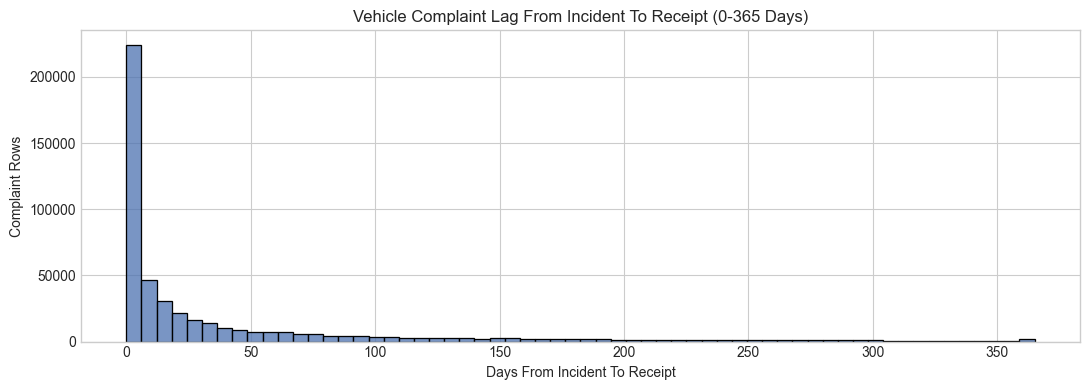

In [13]:
lag_cols = [
    'cmplid',
    'odino',
    'maketxt',
    'modeltxt',
    'yeartxt',
    'faildate',
    'ldate',
    'datea',
    'lag_days',
    'cdescr'
]

lag_non_null = vehicle_std['lag_days'].dropna()
lag_bands = pd.DataFrame([
    {'band': '< 0 days', 'rows': int(lag_non_null.lt(0).sum())},
    {'band': '0 days', 'rows': int(lag_non_null.eq(0).sum())},
    {'band': '1 day', 'rows': int(lag_non_null.eq(1).sum())},
    {'band': '2 to 7 days', 'rows': int(lag_non_null.between(2, 7).sum())},
    {'band': '8 to 30 days', 'rows': int(lag_non_null.between(8, 30).sum())},
    {'band': '31 to 365 days', 'rows': int(lag_non_null.between(31, 365).sum())},
    {'band': '366 to 1000 days', 'rows': int(lag_non_null.between(366, 1000).sum())},
    {'band': '1001+ days','rows': int(lag_non_null.gt(1000).sum())}
])
lag_bands['row_pct'] = (lag_bands['rows'] / len(vehicle_std) * 100).round(4)

negative_lag = vehicle_std.loc[vehicle_std['lag_days'].lt(0), lag_cols].sort_values(['lag_days', 'ldate', 'faildate'])
long_lag = vehicle_std.loc[vehicle_std['lag_days'].gt(1000), lag_cols].sort_values('lag_days', ascending=False).head(10)

print("Vehicle incident-to-receipt lag bands:")
display(lag_bands)

print("\nNegative-lag rows to inspect by hand:")
display(negative_lag)

print("\nVery long-lag rows to inspect for modeling context:")
display(long_lag)

lag_plot = lag_non_null.loc[lag_non_null.between(0, 365)]
plt.figure(figsize=(11, 4))
sns.histplot(lag_plot, bins=60)
plt.title("Vehicle Complaint Lag From Incident To Receipt (0-365 Days)")
plt.xlabel("Days From Incident To Receipt")
plt.ylabel("Complaint Rows")
plt.tight_layout()
plt.show()

### 6.2 Date Field Sanity Beyond Lag

Checks for data edge cases other than just reporting lag such as incident dates that are before the model year of the car and shouldn't be possible.

Date sanity checks for vehicle complaints:


,check,rows,row_pct,current_read
0,fail year < 1990 for a 1990+ vehicle,479,0.0890,very likely data entry noise
1,fail year before model_year - 1,876,0.1628,safe to flag before any time-derived modeling
2,fail year before model_year - 5,742,0.1379,looks too inconsistent to treat as a real incident year
3,fail year < 1980,448,0.0833,mixture of likely bad years and a few legacy vehicles



Most common fail years among pre-model incidents:


,fail_year,rows
0,1969,380
1,2002,63
2,2010,39
3,2000,28
4,2003,27
5,2001,22
6,2020,21
7,2014,20
8,1999,18
9,2012,18



Rows with very old fail years on modern vehicles:


,cmplid,odino,maketxt,modeltxt,yeartxt,faildate,ldate,datea,lag_days,cdescr
21818,1655239,11318723,NISSAN,FRONTIER,2007,1917-01-01,2020-03-19,2020-03-19,37698,DRIVER SEAT BELT DOESN'T RETRACT. PASSENGER FRONT AIRBAG WARNING LIGHTS ON. A/C SWITCH HAS DEAD SPOT POSITION #2.
21819,1655240,11318723,NISSAN,FRONTIER,2007,1917-01-01,2020-03-19,2020-03-19,37698,DRIVER SEAT BELT DOESN'T RETRACT. PASSENGER FRONT AIRBAG WARNING LIGHTS ON. A/C SWITCH HAS DEAD SPOT POSITION #2.
21820,1655241,11318723,NISSAN,FRONTIER,2007,1917-01-01,2020-03-19,2020-03-19,37698,DRIVER SEAT BELT DOESN'T RETRACT. PASSENGER FRONT AIRBAG WARNING LIGHTS ON. A/C SWITCH HAS DEAD SPOT POSITION #2.
32622,1666043,11326567,GMC,YUKON XL,2001,1917-08-15,2020-05-29,2020-05-29,37543,5.3 ENGINE KNOCKS AT START UP. *TR
23121,1656542,11319686,FORD,RANGER,1998,1918-03-28,2020-03-30,2020-03-30,37258,"4WD STOPPED WORKING SOME TIME AGO, SERVO/ACTUATOR SEEMED TO BE FREE, RECENTLY STARTED MAKING GRINDING NOISES IN THE ..."
23122,1656543,11319686,FORD,RANGER,1998,1918-03-28,2020-03-30,2020-03-30,37258,"4WD STOPPED WORKING SOME TIME AGO, SERVO/ACTUATOR SEEMED TO BE FREE, RECENTLY STARTED MAKING GRINDING NOISES IN THE ..."
23123,1656544,11319686,FORD,RANGER,1998,1918-03-28,2020-03-30,2020-03-30,37258,"4WD STOPPED WORKING SOME TIME AGO, SERVO/ACTUATOR SEEMED TO BE FREE, RECENTLY STARTED MAKING GRINDING NOISES IN THE ..."
23970,1657391,11320278,HYUNDAI,VERACRUZ,2008,1918-05-15,2020-04-06,2020-04-06,37217,THE AIR BAG LIGHT WAS ON WHEN I BOUGHT IT AND NOW I AM UNABLE TO HAVE INSPECTEDT TILL IPAYTHE DEALER2;000 I GOT THE ...
51591,1685012,11349598,JEEP,CHEROKEE,2014,1918-08-12,2020-08-15,2020-08-15,37259,"ENGEN LIGHT IS ON, OIL LIGHT IS ON. OIL SENSOR IS NOT WORKING.I AM TOLD THE SENSOR IS CAUSING ALL OF THIS AND A $ 60..."
7415,1640836,11301930,CHEVROLET,COLORADO,2017,1919-08-18,2020-01-26,2020-01-26,36686,"CHEVY SHAKE!.. BEEN EXPERICING A HEAVY SHAKE/VIBRATION SPEEDS OVER 45MPH, IN CITY.. MORE SO ON HIGHWAY TRAVEL, LOOK..."



Rows where fail year is before model year minus one:


,cmplid,odino,maketxt,modeltxt,yeartxt,faildate,ldate,datea,lag_days,cdescr
21818,1655239,11318723,NISSAN,FRONTIER,2007,1917-01-01,2020-03-19,2020-03-19,37698,DRIVER SEAT BELT DOESN'T RETRACT. PASSENGER FRONT AIRBAG WARNING LIGHTS ON. A/C SWITCH HAS DEAD SPOT POSITION #2.
21819,1655240,11318723,NISSAN,FRONTIER,2007,1917-01-01,2020-03-19,2020-03-19,37698,DRIVER SEAT BELT DOESN'T RETRACT. PASSENGER FRONT AIRBAG WARNING LIGHTS ON. A/C SWITCH HAS DEAD SPOT POSITION #2.
21820,1655241,11318723,NISSAN,FRONTIER,2007,1917-01-01,2020-03-19,2020-03-19,37698,DRIVER SEAT BELT DOESN'T RETRACT. PASSENGER FRONT AIRBAG WARNING LIGHTS ON. A/C SWITCH HAS DEAD SPOT POSITION #2.
32622,1666043,11326567,GMC,YUKON XL,2001,1917-08-15,2020-05-29,2020-05-29,37543,5.3 ENGINE KNOCKS AT START UP. *TR
23121,1656542,11319686,FORD,RANGER,1998,1918-03-28,2020-03-30,2020-03-30,37258,"4WD STOPPED WORKING SOME TIME AGO, SERVO/ACTUATOR SEEMED TO BE FREE, RECENTLY STARTED MAKING GRINDING NOISES IN THE ..."
23122,1656543,11319686,FORD,RANGER,1998,1918-03-28,2020-03-30,2020-03-30,37258,"4WD STOPPED WORKING SOME TIME AGO, SERVO/ACTUATOR SEEMED TO BE FREE, RECENTLY STARTED MAKING GRINDING NOISES IN THE ..."
23123,1656544,11319686,FORD,RANGER,1998,1918-03-28,2020-03-30,2020-03-30,37258,"4WD STOPPED WORKING SOME TIME AGO, SERVO/ACTUATOR SEEMED TO BE FREE, RECENTLY STARTED MAKING GRINDING NOISES IN THE ..."
23970,1657391,11320278,HYUNDAI,VERACRUZ,2008,1918-05-15,2020-04-06,2020-04-06,37217,THE AIR BAG LIGHT WAS ON WHEN I BOUGHT IT AND NOW I AM UNABLE TO HAVE INSPECTEDT TILL IPAYTHE DEALER2;000 I GOT THE ...
51591,1685012,11349598,JEEP,CHEROKEE,2014,1918-08-12,2020-08-15,2020-08-15,37259,"ENGEN LIGHT IS ON, OIL LIGHT IS ON. OIL SENSOR IS NOT WORKING.I AM TOLD THE SENSOR IS CAUSING ALL OF THIS AND A $ 60..."
7415,1640836,11301930,CHEVROLET,COLORADO,2017,1919-08-18,2020-01-26,2020-01-26,36686,"CHEVY SHAKE!.. BEEN EXPERICING A HEAVY SHAKE/VIBRATION SPEEDS OVER 45MPH, IN CITY.. MORE SO ON HIGHWAY TRAVEL, LOOK..."


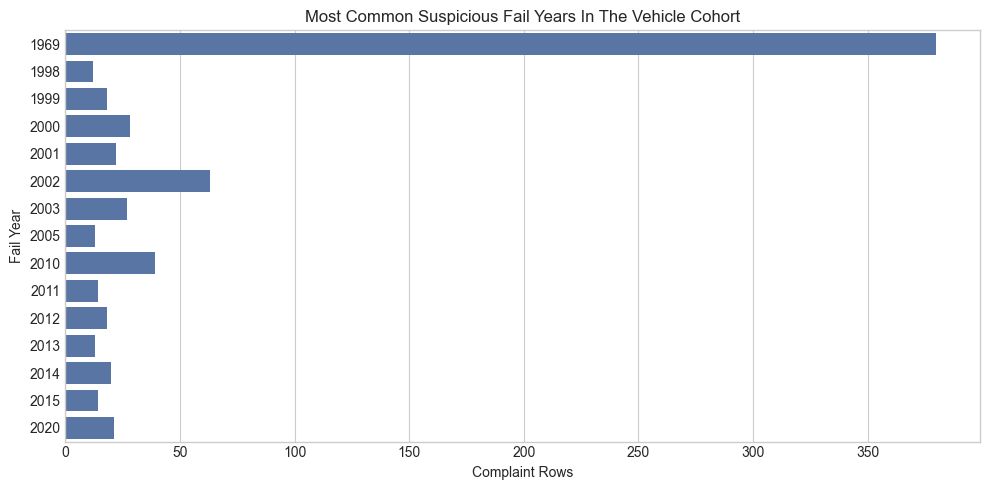

In [14]:
date_cols = [
    'cmplid',
    'odino',
    'maketxt',
    'modeltxt',
    'yeartxt',
    'faildate',
    'ldate',
    'datea',
    'lag_days',
    'cdescr'
]

vehicle_std['fail_year'] = vehicle_std['faildate'].dt.year
vehicle_std['ldate_year'] = vehicle_std['ldate'].dt.year

fail_sanity = pd.DataFrame([
    {
        'check': 'fail year < 1990 for a 1990+ vehicle',
        'rows': int(vehicle_flags['flag_fail_old_new_vehicle'].sum()),
        'row_pct': round(float(vehicle_flags['flag_fail_old_new_vehicle'].sum() / len(vehicle_std) * 100), 4),
        'current_read': 'very likely data entry noise'
    },
    {
        'check': 'fail year before model_year - 1',
        'rows': int(vehicle_flags['flag_fail_pre_model'].sum()),
        'row_pct': round(float(vehicle_flags['flag_fail_pre_model'].sum() / len(vehicle_std) * 100), 4),
        'current_read': 'safe to flag before any time-derived modeling'
    },
    {
        'check': 'fail year before model_year - 5',
        'rows': int(vehicle_flags['flag_fail_pre_model_far'].sum()),
        'row_pct': round(float(vehicle_flags['flag_fail_pre_model_far'].sum() / len(vehicle_std) * 100), 4),
        'current_read': 'looks too inconsistent to treat as a real incident year'
    },
    {
        'check': 'fail year < 1980',
        'rows': int(vehicle_std['fail_year'].lt(1980).sum()),
        'row_pct': round(float(vehicle_std['fail_year'].lt(1980).sum() / len(vehicle_std) * 100), 4),
        'current_read': 'mixture of likely bad years and a few legacy vehicles'
    }
])

odd_fail_years = (
    vehicle_std.loc[vehicle_flags['flag_fail_pre_model'], 'fail_year']
    .value_counts()
    .head(15)
    .rename_axis('fail_year')
    .reset_index(name='rows')
)
old_fail_rows = vehicle_std.loc[vehicle_flags['flag_fail_old_new_vehicle'], date_cols].sort_values(['faildate', 'ldate']).head(12)
pre_model_rows = vehicle_std.loc[vehicle_flags['flag_fail_pre_model'], date_cols].sort_values(['faildate', 'ldate']).head(12)

print("Date sanity checks for vehicle complaints:")
display(fail_sanity)

print("\nMost common fail years among pre-model incidents:")
display(odd_fail_years)

print("\nRows with very old fail years on modern vehicles:")
display(old_fail_rows)

print("\nRows where fail year is before model year minus one:")
display(pre_model_rows)

plt.figure(figsize=(10, 5))
sns.barplot(data=odd_fail_years, x='rows', y='fail_year', orient='h')
plt.title("Most Common Suspicious Fail Years In The Vehicle Cohort")
plt.xlabel("Complaint Rows")
plt.ylabel("Fail Year")
plt.tight_layout()
plt.show()

### 6.3 High Speed Review

We know speeds of 999 are invalid or should be null based on the sentinel value documentation, but we also need to look for unusually high speeds to determine if they should just stay as is, be flagged, or nulled.

Vehicle speed thresholds:


,threshold,rows,row_pct
0,> 120,381,0.0708
1,> 160,342,0.0636
2,> 200,323,0.0600
3,== 999,19,0.0035



Most common values above 200:


,veh_speed,rows
0,999,19
1,354,15
2,510,15
3,657,13
4,455,10
5,700,9
6,450,8
7,606,8
8,650,8
9,600,8



Makes most represented among speeds above 200:


,maketxt,rows
0,FORD,55
1,CHEVROLET,34
2,NISSAN,25
3,JEEP,24
4,TESLA,22
5,HYUNDAI,17
6,HONDA,17
7,SUBARU,14
8,MERCEDES-BENZ,13
9,KIA,13



Rows above 200 to inspect by hand:


,cmplid,odino,maketxt,modeltxt,yeartxt,veh_speed,miles,faildate,cdescr
472197,2105697,11670504,NISSAN,ALTIMA,2016,999,104000,2025-06-16,"The contact owns a 2016 Nissan Altima. The contact stated that while starting the vehicle, the fuel gauge indicated ..."
461911,2095411,11663370,BMW,X5,2020,999,80000,2025-05-28,"The contact owns a 2020 BMW X5. The contact stated that upon entering the vehicle, the message that the engine had o..."
468315,2101815,11667780,TOYOTA,TACOMA,2004,999,20000,2025-04-18,"The contact owns a 2004 Toyota Tacoma equipped with Toyo Tires, Tire Line: Open Country HT, Tire Size: 265/70/R16, D..."
468316,2101816,11667780,TOYOTA,TACOMA,2004,999,20000,2025-04-18,"The contact owns a 2004 Toyota Tacoma equipped with Toyo Tires, Tire Line: Open Country HT, Tire Size: 265/70/R16, D..."
454101,2087601,11657893,HONDA,FIT,2015,999,79852,2025-04-29,"The contact owns a 2015 Honda Fit. The contact stated that while operating the vehicle, the transmission warning lig..."
377615,2011114,11604867,VOLKSWAGEN,ID.4,2021,999,<NA>,2024-07-13,Infotainment screen and instrument cluster turned off mid driving. This lead to complete failure of speed indicator....
377614,2011113,11604867,VOLKSWAGEN,ID.4,2021,999,<NA>,2024-07-13,Infotainment screen and instrument cluster turned off mid driving. This lead to complete failure of speed indicator....
461910,2095410,11663370,BMW,X5,2020,999,80000,2025-05-28,"The contact owns a 2020 BMW X5. The contact stated that upon entering the vehicle, the message that the engine had o..."
262278,1895720,11522603,RAM,2500,2018,999,5500,2020-09-01,"The contact owns a 2018 Ram 2500. The contact stated that while driving at an undisclosed speed, the ABS warning lig..."
255241,1888662,11517710,SUBARU,OUTBACK,2019,999,39000,2023-03-08,"The contact owns a 2019 Subaru Outback. The contact stated that upon entering the vehicle, he became aware of a crac..."


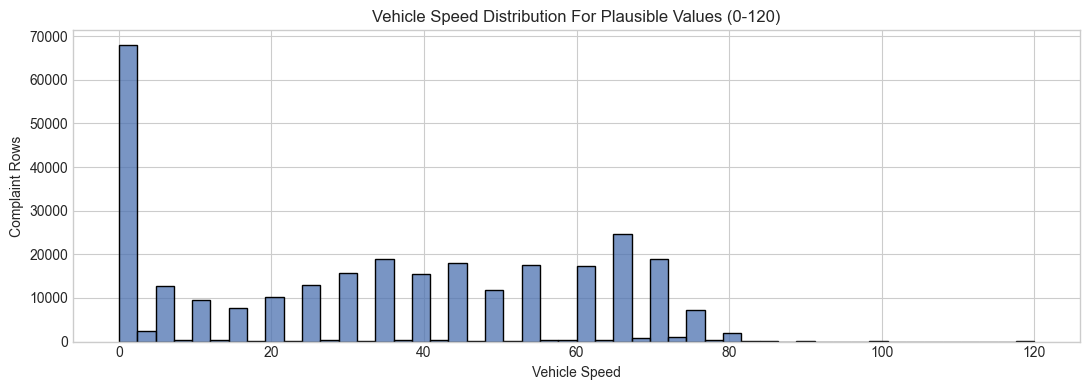

In [15]:
speed_cols = [
    'cmplid',
    'odino',
    'maketxt',
    'modeltxt',
    'yeartxt',
    'veh_speed',
    'miles',
    'faildate',
    'cdescr'
]

speed_thresholds = pd.DataFrame([
    {'threshold': '> 120', 'rows': int(vehicle_std['veh_speed'].gt(120).sum())},
    {'threshold': '> 160', 'rows': int(vehicle_std['veh_speed'].gt(160).sum())},
    {'threshold': '> 200', 'rows': int(vehicle_std['veh_speed'].gt(200).sum())},
    {'threshold': '== 999', 'rows': int(vehicle_std['veh_speed'].eq(999).sum())}
])
speed_thresholds['row_pct'] = (speed_thresholds['rows'] / len(vehicle_std) * 100).round(4)

high_speed_vals = (
    vehicle_std.loc[vehicle_std['veh_speed'].gt(200), 'veh_speed']
    .value_counts()
    .head(15)
    .rename_axis('veh_speed')
    .reset_index(name='rows')
)

high_speed_makes = (
    vehicle_std.loc[vehicle_std['veh_speed'].gt(200), 'maketxt']
    .value_counts()
    .head(10)
    .rename_axis('maketxt')
    .reset_index(name='rows')
)

high_speed_rows = vehicle_std.loc[vehicle_std['veh_speed'].gt(200), speed_cols].sort_values('veh_speed', ascending=False).head(12)

print("Vehicle speed thresholds:")
display(speed_thresholds)

print("\nMost common values above 200:")
display(high_speed_vals)

print("\nMakes most represented among speeds above 200:")
display(high_speed_makes)

print("\nRows above 200 to inspect by hand:")
display(high_speed_rows)

plot_speed = vehicle_std.loc[vehicle_std['veh_speed'].between(0, 120), 'veh_speed'].dropna()
plt.figure(figsize=(11, 4))
sns.histplot(plot_speed, bins=50)
plt.title("Vehicle Speed Distribution For Plausible Values (0-120)")
plt.xlabel("Vehicle Speed")
plt.ylabel("Complaint Rows")
plt.tight_layout()
plt.show()

### 6.4 High Mileage Review

Mileage is trickier than speed because very high values can be real for heavily used vehicles. This helps review the pattern and distribution of values to help decide whether values should be kept, flagged, clipped, or nulled later.

Vehicle mileage thresholds:


,threshold,rows,row_pct
0,> 200000,4139,0.7694
1,> 300000,685,0.1273
2,> 500000,348,0.0647
3,> 1000000,156,0.0290



Most common values above 500000 miles:


,miles,rows
0,700000,11
1,630000,10
2,980000,9
3,1400000,7
4,1000000,6
5,600000,6
6,780000,6
7,540000,5
8,900000,4
9,1140000,4



Makes most represented among mileages above 500000:


,maketxt,rows
0,CHEVROLET,64
1,FORD,54
2,NISSAN,25
3,KIA,22
4,TOYOTA,21
5,DODGE,18
6,JEEP,17
7,GMC,14
8,CHRYSLER,12
9,HYUNDAI,11



Rows above 500000 miles to inspect by hand:


,cmplid,odino,maketxt,modeltxt,yeartxt,miles,veh_speed,faildate,cdescr
69350,1702771,11366781,HYUNDAI,AZERA,2014,9848609,60,2020-10-22,MY AIRBAG LIGHT JUST STARTED COMING ON OCT 28 2020 & OFF . BUT THE NOISES BEEN COMING ON & OFF SCENE APRIL 20TH 20...
20065,1653486,11317361,HYUNDAI,ELANTRA,2013,9800000,<NA>,2020-01-01,THE STEERING HAS BECOME LOOSE AN KLUNKS WHEN THE STEERING WHEEL IS MOVED BACK AND FORTH FROM CIENTER POSITION . IT D...
24869,1658290,11320959,MAZDA,MAZDA6,2014,9800000,<NA>,2020-03-24,I WAS AT WALMART ABOUT 3 WEEKS AGO AND WHEN I FINISHED SHOPPING I CAME OUT TO MY VEHICLE IN AN ALMOST EMPTY PARKING...
213646,1847067,11488955,FORD,EXPLORER,2015,9400070,70,2022-09-09,The contact owns a 2015 Ford Explorer. The contact stated that while driving approximately 70 mph in the rain when t...
34153,1667574,11327654,ACURA,TLX,2015,9000000,<NA>,2020-06-07,"ON JUNE 7TH 2020 I WAS DRIVING MY CAR , IT STARTED TO SHAKE. AS I STARTED TO DRIVE BACK HOME TO SEE WHAT WAS GOING..."
34152,1667573,11327654,ACURA,TLX,2015,9000000,<NA>,2020-06-07,"ON JUNE 7TH 2020 I WAS DRIVING MY CAR , IT STARTED TO SHAKE. AS I STARTED TO DRIVE BACK HOME TO SEE WHAT WAS GOING..."
34151,1667572,11327654,ACURA,TLX,2015,9000000,<NA>,2020-06-07,"ON JUNE 7TH 2020 I WAS DRIVING MY CAR , IT STARTED TO SHAKE. AS I STARTED TO DRIVE BACK HOME TO SEE WHAT WAS GOING..."
34007,1667428,11327548,CHEVROLET,TRAILBLAZER,2005,7156000,55,2020-05-20,MY GAS GAUGE IS SITTING ON BOTTOM INSTEAD OF TOP WHERE IT'S SUPPOSED TO BE. I DON'T KNOW HOW MUCH GAS IN MY CAR. AN ...
34006,1667427,11327548,CHEVROLET,TRAILBLAZER,2005,7156000,55,2020-05-20,MY GAS GAUGE IS SITTING ON BOTTOM INSTEAD OF TOP WHERE IT'S SUPPOSED TO BE. I DON'T KNOW HOW MUCH GAS IN MY CAR. AN ...
34005,1667426,11327548,CHEVROLET,TRAILBLAZER,2005,7156000,55,2020-05-20,MY GAS GAUGE IS SITTING ON BOTTOM INSTEAD OF TOP WHERE IT'S SUPPOSED TO BE. I DON'T KNOW HOW MUCH GAS IN MY CAR. AN ...


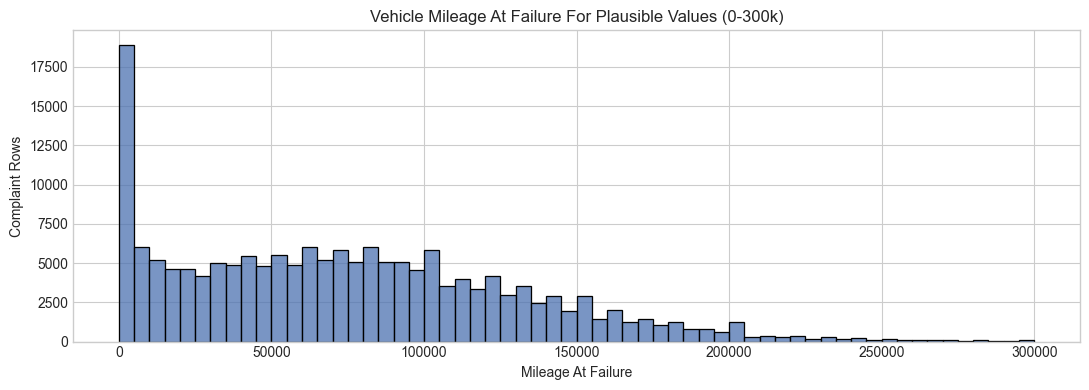

In [16]:
miles_cols = [
    'cmplid',
    'odino',
    'maketxt',
    'modeltxt',
    'yeartxt',
    'miles',
    'veh_speed',
    'faildate',
    'cdescr'
]

miles_thresholds = pd.DataFrame([
    {'threshold': '> 200000', 'rows': int(vehicle_std['miles'].gt(200000).sum())},
    {'threshold': '> 300000', 'rows': int(vehicle_std['miles'].gt(300000).sum())},
    {'threshold': '> 500000', 'rows': int(vehicle_std['miles'].gt(500000).sum())},
    {'threshold': '> 1000000', 'rows': int(vehicle_std['miles'].gt(1000000).sum())}
])
miles_thresholds['row_pct'] = (miles_thresholds['rows'] / len(vehicle_std) * 100).round(4)

high_miles_vals = (
    vehicle_std.loc[vehicle_std['miles'].gt(500000), 'miles']
    .value_counts()
    .head(15)
    .rename_axis('miles')
    .reset_index(name='rows')
)

high_miles_makes = (
    vehicle_std.loc[vehicle_std['miles'].gt(500000), 'maketxt']
    .value_counts()
    .head(10)
    .rename_axis('maketxt')
    .reset_index(name='rows')
)

high_miles_rows = vehicle_std.loc[vehicle_std['miles'].gt(500000), miles_cols].sort_values('miles', ascending=False).head(12)

print("Vehicle mileage thresholds:")
display(miles_thresholds)

print("\nMost common values above 500000 miles:")
display(high_miles_vals)

print("\nMakes most represented among mileages above 500000:")
display(high_miles_makes)

print("\nRows above 500000 miles to inspect by hand:")
display(high_miles_rows)

plot_miles = vehicle_std.loc[vehicle_std['miles'].between(0, 300000), 'miles'].dropna()
plt.figure(figsize=(11, 4))
sns.histplot(plot_miles, bins=60)
plt.title("Vehicle Mileage At Failure For Plausible Values (0-300k)")
plt.xlabel("Mileage At Failure")
plt.ylabel("Complaint Rows")
plt.tight_layout()
plt.show()

### 6.5 Zero Review By Field

The source data documents a schema shift in the middle of our data where initally missing data for certain numeric fields was kept as null, but they changed it later to be inserted as a zero. Therefore, we cannot assume that zeros automatically mean zero and we need to check whether the values look like real observed zeros or something more ambiguous.

Zero review by field:


,field,non_null_rows,zero_rows,zero_pct_of_non_null,positive_rows,positive_pct_of_non_null,current_read
0,injured,537936,523761,97.36,14175,2.64,keep zero for now because positive injury counts appear consistently every year
1,deaths,537936,537459,99.91,477,0.09,keep zero for now because the field behaves like a sparse count rather than a placeholder bucket
2,miles,170200,5136,3.02,165064,96.98,keep zero but treat it as ambiguous and worth a dedicated flag later
3,veh_speed,298129,62853,21.08,235276,78.92,keep zero but treat it as context-dependent because many complaints happen while parked or starting up



Zero and positive rates before and after the 2021 file change window:


,field,period,non_null_rows,zero_pct_of_non_null,positive_pct_of_non_null
0,injured,2020-2021,151092,97.00,3.00
1,deaths,2020-2021,151092,99.89,0.11
2,miles,2020-2021,102241,2.08,97.92
3,veh_speed,2020-2021,100326,25.09,74.91
4,injured,2022-2026,386844,97.51,2.49
5,deaths,2022-2026,386844,99.92,0.08
6,miles,2022-2026,67959,4.43,95.57
7,veh_speed,2022-2026,197803,19.05,80.95



Examples where injured > 0:


...

,cmplid,odino,maketxt,modeltxt,ldate,miles,veh_speed,injured,deaths,cdescr
802,1634223,11296971,TOYOTA,COROLLA,2020-01-03,<NA>,5,1,1,"THE 2005 COROLLA WAS SLOWED DOWN FOR TRAFFIC AHEAD ON THE HIGHWAY AND REAR ENDED BY A DRIVER, WHO THEN COLLIDED WIT..."
5044,1638465,11300232,NISSAN,ARMADA,2020-01-18,85000,50,1,2,MY WIFE WAS KILLED IN A HEAD ON COLLISION. DIED FROM BLUNT FORCE TRAUMA TO THE CHEST. THE STEERING WHEEL WAS BENT. *...
8311,1641732,11302656,TESLA,MODEL 3,2020-01-28,<NA>,55,0,1,"THE DRIVER WAS INVOLVED IN A FATAL ACCIDENT IN WHICH THE AUTO-PILOT AND/OR LANE-ASSIST FEATURES FAILED, CAUSING THE ..."
8312,1641733,11302656,TESLA,MODEL 3,2020-01-28,<NA>,55,0,1,"THE DRIVER WAS INVOLVED IN A FATAL ACCIDENT IN WHICH THE AUTO-PILOT AND/OR LANE-ASSIST FEATURES FAILED, CAUSING THE ..."
8313,1641734,11302656,TESLA,MODEL 3,2020-01-28,<NA>,55,0,1,"THE DRIVER WAS INVOLVED IN A FATAL ACCIDENT IN WHICH THE AUTO-PILOT AND/OR LANE-ASSIST FEATURES FAILED, CAUSING THE ..."
8761,1642182,11302960,TOYOTA,COROLLA,2020-01-30,<NA>,40,1,1,"ON 01-22-20, IN AUSTIN TEXAS MY DAUGHTER, [XXX], WAS KILLED IN A HEAD ON COLLISION WHILE SHE WAS DRIVING HER 2007 TO..."
8762,1642183,11302960,TOYOTA,COROLLA,2020-01-30,<NA>,40,1,1,"ON 01-22-20, IN AUSTIN TEXAS MY DAUGHTER, [XXX], WAS KILLED IN A HEAD ON COLLISION WHILE SHE WAS DRIVING HER 2007 TO..."
9686,1643107,11306689,VOLKSWAGEN,TIGUAN,2020-02-03,3834,45,1,1,"TL* THE CONTACT OWNS A 2017 VOLKSWAGEN TIGUAN. THE CONTACT STATED THAT WHILE DRIVING AT 45 MPH, THE CONTACT HIT A PO..."



Examples where miles == 0:


,cmplid,odino,maketxt,modeltxt,ldate,miles,veh_speed,injured,deaths,cdescr
120,1633541,11292452,FORD,FOCUS,2020-01-01,0,<NA>,0,0,TRANSMISSION WORK TEMPORARILY IN REVERSE. THEN REVERSE GOES OUT COMPLETELY. I'M ABOUT TO TAKE THE VEHICLE BACK FOR R...
179,1633600,11292503,SUBARU,CROSSTREK,2020-01-01,0,0,0,0,NO VISBILITY OF CRACK BEFORE WORK. 9 HOURS LATER A LARGE CRACK APPEARS ON WINDSHIELD. CAR WAS PARKED IN GATED SECURE...
336,1633757,11296637,JEEP,GRAND CHEROKEE,2020-01-02,0,30,0,0,I WAS DRIVING MY 2011 JEEP GRAND CHEROKEE DOWN A CITY STREET WHEN WITH OUT ANY WARNING THE VEHICLE COMPLETELY CUT O...
337,1633758,11296637,JEEP,GRAND CHEROKEE,2020-01-02,0,30,0,0,I WAS DRIVING MY 2011 JEEP GRAND CHEROKEE DOWN A CITY STREET WHEN WITH OUT ANY WARNING THE VEHICLE COMPLETELY CUT O...
469,1633890,11296724,TOYOTA,RAV4,2020-01-02,0,0,0,0,"PURCHASED A NEW 2019 TOYOTA RAV4 HYBRID AWD XLE ON 10/24/19. FUEL CAPACITY APPEARS TO BE ABOUT 11 GALLONS, AS OPPOS..."
478,1633899,11296736,MERCEDES-BENZ,C300,2020-01-02,0,0,0,0,STEERING CONTROL LOCK UNIT HAS GONE BAD MANY ISSUES CAR WILL NOT START LEAVES YOU STRANDED MANY PEOPLE COMPLAINING ...
904,1634325,11297049,HONDA,ACCORD,2020-01-04,0,0,0,0,HI WE'LL ALL I COULD SAID THAT PARK MY CAR ON 53TH ST AND HOOPER YESTERDAY AT 11PM WAS MY LAST SEEN OF THE CAR IS A ...
1519,1634940,11297480,MERCURY,MILAN,2020-01-06,0,55,0,0,"BRAKE HYDRALIC WARNING LIGHT COMES ON '- THERE IS A BRAKE RECALL ON MY CAR. DEALER SAYS ,WAIT FOR PARTS '' EVEN WITH..."
1520,1634941,11297481,GMC,ACADIA,2020-01-06,0,0,0,0,"I TURNED THE CAR OFF AND IT DISPLAYS A MESSAGE 'SHIFT TO PARK,' EVEN THOUGH THE CAR IS IN PARK. IT DOESN'T ALLOW THE..."
1521,1634942,11297481,GMC,ACADIA,2020-01-06,0,0,0,0,"I TURNED THE CAR OFF AND IT DISPLAYS A MESSAGE 'SHIFT TO PARK,' EVEN THOUGH THE CAR IS IN PARK. IT DOESN'T ALLOW THE..."



Examples where veh_speed == 0:


,cmplid,odino,maketxt,modeltxt,ldate,miles,veh_speed,injured,deaths,cdescr
3,1633424,11292385,FORD,EXPLORER,2020-01-01,5300,0,0,0,DEEP SLEEP MODE ACTIVATES AFTER 2 DAYS. MOST RECENT EXPERIENCE INVOLVED HAVING TO JUMP START THE CAR AFTER SETTING ...
8,1633429,11292388,CHEVROLET,MALIBU,2020-01-01,200000,0,0,0,THE POWER STEERING WILL OCCASIONALLY NOT WORK WHEN YOU START THE CAR BUT IF YOU TURN IT OFF AND START IT UP AGAIN IT...
32,1633453,11292405,CHEVROLET,SILVERADO 1500,2020-01-01,53000,0,0,0,LOSS OF POWER STEERING ASSIST WHEN FIRST STARTING THE VEHICLE. A MESSAGE IS DISPLAYED ON THE INFO PANEL IN THE CENT...
33,1633454,11292405,CHEVROLET,SILVERADO 1500,2020-01-01,53000,0,0,0,LOSS OF POWER STEERING ASSIST WHEN FIRST STARTING THE VEHICLE. A MESSAGE IS DISPLAYED ON THE INFO PANEL IN THE CENT...
48,1633469,11292409,FORD,FOCUS,2020-01-01,106125,0,0,0,"ON JULY 7, 2015, I BOUGHT 4 TIRES 117632 AFFINITY TOURING BL P195/60R15 87T WITH A 70,0000 MILE WARRANTY. I PAID $..."
55,1633476,11292417,HONDA,CR-V,2020-01-01,<NA>,0,0,0,MY VEHICLE IS SUFFERING FROM AN EXTREMELY COMMON PROBLEM WITHIN THE 4TH GENERATION CRV - THE VTC ACTUATOR IS MAKING ...
90,1633511,11292443,HONDA,CR-V,2020-01-01,<NA>,0,0,0,THE SHIFT BUTTON ON THE AUTOMATIC TRANSMISSION SHIFTER FELL OFF. IT IS BROKE SO THE CAR CANNON BE PUT BACK INTO PARK.
107,1633528,11292451,HONDA,CR-V,2020-01-01,36000,0,0,0,"THE EMISSIONS LIGHT CAME ON, STARTED TO HAVE AN ODOR OF GASOLINE IN THE CABIN, FUEL MILAGE HAS DECREASED, ROUGH IDLE..."
108,1633529,11292451,HONDA,CR-V,2020-01-01,36000,0,0,0,"THE EMISSIONS LIGHT CAME ON, STARTED TO HAVE AN ODOR OF GASOLINE IN THE CABIN, FUEL MILAGE HAS DECREASED, ROUGH IDLE..."
109,1633530,11292451,HONDA,CR-V,2020-01-01,36000,0,0,0,"THE EMISSIONS LIGHT CAME ON, STARTED TO HAVE AN ODOR OF GASOLINE IN THE CABIN, FUEL MILAGE HAS DECREASED, ROUGH IDLE..."


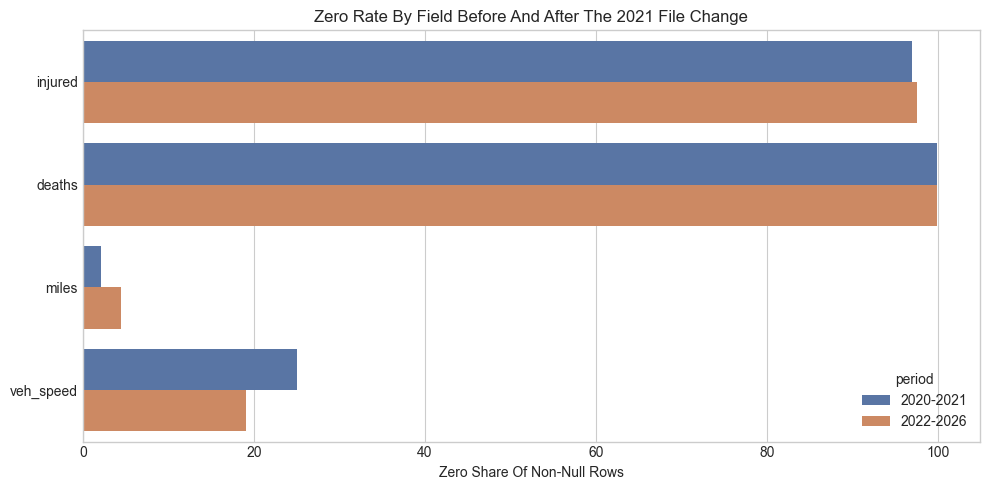

In [17]:
zero_cols = [
    'cmplid',
    'odino',
    'maketxt',
    'modeltxt',
    'ldate',
    'miles',
    'veh_speed',
    'injured',
    'deaths',
    'cdescr'
]

zero_fields = [
    'injured',
    'deaths',
    'miles',
    'veh_speed'
]

zero_read = {
    'injured': 'keep zero for now because positive injury counts appear consistently every year',
    'deaths': 'keep zero for now because the field behaves like a sparse count rather than a placeholder bucket',
    'miles': 'keep zero but treat it as ambiguous and worth a dedicated flag later',
    'veh_speed': 'keep zero but treat it as context-dependent because many complaints happen while parked or starting up'
}

zero_summary_rows = []
for col in zero_fields:
    non_null = int(vehicle_std[col].notna().sum())
    zero_rows = int(vehicle_std[col].eq(0).sum())
    positive_rows = int(vehicle_std[col].gt(0).sum())
    zero_summary_rows.append({
        'field': col,
        'non_null_rows': non_null,
        'zero_rows': zero_rows,
        'zero_pct_of_non_null': round(float(zero_rows / non_null * 100), 2),
        'positive_rows': positive_rows,
        'positive_pct_of_non_null': round(float(positive_rows / non_null * 100), 2),
        'current_read': zero_read[col]
    })
zero_summary = pd.DataFrame(zero_summary_rows)

period_rows = []
for period_name, mask in [
    ('2020-2021', vehicle_std['ldate_year'].le(2021)),
    ('2022-2026', vehicle_std['ldate_year'].ge(2022))
]:
    part = vehicle_std.loc[mask]
    for col in zero_fields:
        non_null = int(part[col].notna().sum())
        zero_rows = int(part[col].eq(0).sum())
        positive_rows = int(part[col].gt(0).sum())
        period_rows.append({
            'field': col,
            'period': period_name,
            'non_null_rows': non_null,
            'zero_pct_of_non_null': round(float(zero_rows / non_null * 100), 2),
            'positive_pct_of_non_null': round(float(positive_rows / non_null * 100), 2)
        })
zero_period = pd.DataFrame(period_rows)

injury_examples = vehicle_std.loc[vehicle_std['injured'].gt(0), zero_cols].head(8)
death_examples = vehicle_std.loc[vehicle_std['deaths'].gt(0), zero_cols].head(8)
zero_miles_examples = vehicle_std.loc[vehicle_std['miles'].eq(0), zero_cols].head(10)
zero_speed_examples = vehicle_std.loc[vehicle_std['veh_speed'].eq(0), zero_cols].head(10)

print("Zero review by field:")
display(zero_summary)

print("\nZero and positive rates before and after the 2021 file change window:")
display(zero_period)

print("\nExamples where injured > 0:")
display(injury_examples)

print("\nExamples where deaths > 0:")
display(death_examples)

print("\nExamples where miles == 0:")
display(zero_miles_examples)

print("\nExamples where veh_speed == 0:")
display(zero_speed_examples)

plt.figure(figsize=(10, 5))
sns.barplot(data=zero_period, x='zero_pct_of_non_null', y='field', hue='period')
plt.title("Zero Rate By Field Before And After The 2021 File Change")
plt.xlabel("Zero Share Of Non-Null Rows")
plt.ylabel("")
plt.tight_layout()
plt.show()

### 6.6 Current Direction After Review

My current thoughts on what is safe to do now and what should stay as a not fully locked in based on what we've seen so far. These are for both the initial cleaned layer that will be used across models and for general analysis as well as what to do for the model-ready preprocessed data.

In [18]:
review_takeaways = pd.DataFrame([
    {
        'topic': 'date anchor',
        'base_clean_lean': 'keep raw dates',
        'model_ready_lean': 'use ldate as the anchor for all first-pass model tables',
        'why': 'receipt date is the cleanest operational time point in the current extract'
    },
    {
        'topic': 'faildate trust rule',
        'base_clean_lean': 'keep raw faildate but add trust and untrusted flags',
        'model_ready_lean': "derive lag only when faildate <= ldate and fail_year >= model_year - 1",
        'why': 'this keeps useful incident timing while blocking the obviously broken date cases'
    },
    {
        'topic': 'miles and veh_speed zeros',
        'base_clean_lean': 'keep zeros as raw values',
        'model_ready_lean': 'add missingness flags but not zero flags in v1',
        'why': 'zero can be semantically mixed, but missingness is the stronger first-pass signal'
    },
    {
        'topic': 'severity label',
        'base_clean_lean': 'create row-level primary and broad severity flags',
        'model_ready_lean': "collapse the primary flag to an odino-level case table for severity ranking",
        'why': 'severity ranking should prioritize complaints, not overweight complaints that were split into more component rows'
    },
    {
        'topic': 'severity baseline features',
        'base_clean_lean': 'leave target-defining severity columns in the base layer',
        'model_ready_lean': 'exclude injured, deaths, fire, crash, medical_attn, vehicles_towed_yn, and datea from the first baseline',
        'why': 'this keeps the severity model leakage-safe'
    },
    {
        'topic': 'component model table',
        'base_clean_lean': 'keep the vehicle complaint-component rows',
        'model_ready_lean': 'use compdesc as the raw target source until cleaned component groups are finalized',
        'why': 'the component task naturally lives on the complaint-component row rather than the collapsed case row'
    }
])

display(review_takeaways)

,topic,base_clean_lean,model_ready_lean,why
0,date anchor,keep raw dates,use ldate as the anchor for all first-pass model tables,receipt date is the cleanest operational time point in the current extract
1,faildate trust rule,keep raw faildate but add trust and untrusted flags,derive lag only when faildate <= ldate and fail_year >= model_year - 1,this keeps useful incident timing while blocking the obviously broken date cases
2,miles and veh_speed zeros,keep zeros as raw values,add missingness flags but not zero flags in v1,"zero can be semantically mixed, but missingness is the stronger first-pass signal"
3,severity label,create row-level primary and broad severity flags,collapse the primary flag to an odino-level case table for severity ranking,"severity ranking should prioritize complaints, not overweight complaints that were split into more component rows"
4,severity baseline features,leave target-defining severity columns in the base layer,"exclude injured, deaths, fire, crash, medical_attn, vehicles_towed_yn, and datea from the first baseline",this keeps the severity model leakage-safe
5,component model table,keep the vehicle complaint-component rows,use compdesc as the raw target source until cleaned component groups are finalized,the component task naturally lives on the complaint-component row rather than the collapsed case row


## 7. High Confidence Candidate Decisions

Gives a quick overview of the cleaning decisions that are essentially confirmed, why, and what they are affecting. Also includes the candidate derived features that are strong contenders to be included.

In [19]:
candidate_df = std_df.copy()

candidate_df.loc[flag_df['flag_prod_type_bad'], 'prod_type'] = pd.NA
candidate_df.loc[flag_df['flag_year_unknown'] | flag_df['flag_year_out_of_range'], 'yeartxt'] = pd.NA
candidate_df.loc[flag_df['flag_speed_999'], 'veh_speed'] = pd.NA
candidate_df.loc[flag_df['flag_injured_99'], 'injured'] = pd.NA
candidate_df.loc[flag_df['flag_deaths_99'], 'deaths'] = pd.NA
candidate_df.loc[flag_df['flag_state_bad'], 'state'] = pd.NA
candidate_df.loc[flag_df['flag_dealer_state_bad'], 'dealer_state'] = pd.NA

known_model_year = candidate_df['yeartxt'].notna()
fail_year = candidate_df['faildate'].dt.year
trusted_faildate = (
    candidate_df['faildate'].notna()
    & candidate_df['ldate'].notna()
    & candidate_df['faildate'].le(candidate_df['ldate'])
    & (~known_model_year | fail_year.ge(candidate_df['yeartxt'] - 1))
)

candidate_df['miles_missing_flag'] = candidate_df['miles'].isna().astype('Int8')
candidate_df['veh_speed_missing_flag'] = candidate_df['veh_speed'].isna().astype('Int8')
candidate_df['faildate_trusted_flag'] = trusted_faildate.astype('Int8')
candidate_df['faildate_untrusted_flag'] = (candidate_df['faildate'].notna() & ~trusted_faildate).astype('Int8')
candidate_df['lag_days_safe'] = pd.Series(pd.NA, index=candidate_df.index, dtype='Int64')
candidate_df.loc[trusted_faildate, 'lag_days_safe'] = (
    candidate_df.loc[trusted_faildate, 'ldate'] - candidate_df.loc[trusted_faildate, 'faildate']
).dt.days.astype('Int64')

candidate_df['severity_primary_row_flag'] = (
    candidate_df['deaths'].fillna(0).gt(0)
    | candidate_df['injured'].fillna(0).gt(0)
    | candidate_df['fire'].eq('Y').fillna(False)
    | candidate_df['crash'].eq('Y').fillna(False)
).astype('Int8')

candidate_df['severity_broad_row_flag'] = (
    candidate_df['severity_primary_row_flag'].eq(1)
    | candidate_df['medical_attn'].eq('Y').fillna(False)
    | candidate_df['vehicles_towed_yn'].eq('Y').fillna(False)
).astype('Int8')

candidate_rules = pd.DataFrame([
    {
        'field_or_feature': 'prod_type',
        'rule': 'invalid product type to missing',
        'affected_rows': int(flag_df['flag_prod_type_bad'].fillna(False).sum()),
        'why': 'schema-coded field with a small and explicit valid set'
    },
    {
        'field_or_feature': 'yeartxt',
        'rule': '9999 and out-of-range values to missing',
        'affected_rows': int((flag_df['flag_year_unknown'] | flag_df['flag_year_out_of_range']).fillna(False).sum()),
        'why': 'CMPL.txt documents 9999 as unknown and extreme years are not usable model years'
    },
    {
        'field_or_feature': 'veh_speed',
        'rule': '999 sentinel to missing',
        'affected_rows': int(flag_df['flag_speed_999'].fillna(False).sum()),
        'why': '999 behaves like a placeholder value'
    },
    {
        'field_or_feature': 'injured / deaths',
        'rule': '99 sentinel to missing',
        'affected_rows': int(flag_df['flag_injured_99'].fillna(False).sum() + flag_df['flag_deaths_99'].fillna(False).sum()),
        'why': '99 is not a plausible person-count code here'
    },
    {
        'field_or_feature': 'state / dealer_state',
        'rule': 'invalid codes to missing',
        'affected_rows': int(flag_df['flag_state_bad'].fillna(False).sum() + flag_df['flag_dealer_state_bad'].fillna(False).sum()),
        'why': 'invalid geography codes are not analytically useful as location features'
    },
    {
        'field_or_feature': 'lag_days_safe',
        'rule': "derive only when faildate <= ldate and fail_year >= model_year - 1",
        'affected_rows': int(trusted_faildate.sum()),
        'why': 'keeps incident-date features while blocking clearly broken or incompatible dates'
    },
    {
        'field_or_feature': 'miles_missing_flag / veh_speed_missing_flag',
        'rule': 'add missingness indicators for first structured baselines',
        'affected_rows': int(candidate_df['miles_missing_flag'].sum() + candidate_df['veh_speed_missing_flag'].sum()),
        'why': 'missingness is useful while zero stays a raw value rather than a new flag'
    },
    {
        'field_or_feature': 'severity_primary_row_flag',
        'rule': "1 if deaths > 0 or injured > 0 or fire == 'Y' or crash == 'Y'",
        'affected_rows': int(candidate_df['severity_primary_row_flag'].sum()),
        'why': 'this is the first-pass severity label that will later be collapsed to odino level'
    },
    {
        'field_or_feature': 'severity_broad_row_flag',
        'rule': "primary label plus medical_attn == 'Y' or vehicles_towed_yn == 'Y'",
        'affected_rows': int(candidate_df['severity_broad_row_flag'].sum()),
        'why': 'use this only as a sensitivity label, not the main target'
    }
])

candidate_features = pd.DataFrame([
    {
        'feature': 'faildate_trusted_flag',
        'row_count': int(candidate_df['faildate_trusted_flag'].sum())
    },
    {
        'feature': 'faildate_untrusted_flag',
        'row_count': int(candidate_df['faildate_untrusted_flag'].sum())
    },
    {
        'feature': 'lag_days_safe non-null',
        'row_count': int(candidate_df['lag_days_safe'].notna().sum())
    },
    {
        'feature': 'miles_missing_flag',
        'row_count': int(candidate_df['miles_missing_flag'].sum())
    },
    {
        'feature': 'veh_speed_missing_flag',
        'row_count': int(candidate_df['veh_speed_missing_flag'].sum())
    },
    {
        'feature': 'severity_primary_row_flag',
        'row_count': int(candidate_df['severity_primary_row_flag'].sum())
    },
    {
        'feature': 'severity_broad_row_flag',
        'row_count': int(candidate_df['severity_broad_row_flag'].sum())
    }
])

print("Locked candidate rules:")
display(candidate_rules)

print()
print("Key model-ready features from this pass:")
display(candidate_features)

Locked candidate rules:


,field_or_feature,rule,affected_rows,why
0,prod_type,invalid product type to missing,0,schema-coded field with a small and explicit valid set
1,yeartxt,9999 and out-of-range values to missing,7708,CMPL.txt documents 9999 as unknown and extreme years are not usable model years
2,veh_speed,999 sentinel to missing,19,999 behaves like a placeholder value
3,injured / deaths,99 sentinel to missing,13,99 is not a plausible person-count code here
4,state / dealer_state,invalid codes to missing,54,invalid geography codes are not analytically useful as location features
5,lag_days_safe,derive only when faildate <= ldate and fail_year >= model_year - 1,544347,keeps incident-date features while blocking clearly broken or incompatible dates
6,miles_missing_flag / veh_speed_missing_flag,add missingness indicators for first structured baselines,622152,missingness is useful while zero stays a raw value rather than a new flag
7,severity_primary_row_flag,1 if deaths > 0 or injured > 0 or fire == 'Y' or crash == 'Y',37527,this is the first-pass severity label that will later be collapsed to odino level
8,severity_broad_row_flag,primary label plus medical_attn == 'Y' or vehicles_towed_yn == 'Y',51897,"use this only as a sensitivity label, not the main target"



Key model-ready features from this pass:


,feature,row_count
0,faildate_trusted_flag,544347
1,faildate_untrusted_flag,884
2,lag_days_safe non-null,544347
3,miles_missing_flag,375031
4,veh_speed_missing_flag,247121
5,severity_primary_row_flag,37527
6,severity_broad_row_flag,51897


### 7.1 Impact Summary

Compares the null percentage of the candidate cleaning against the earlier layer to see what, if anything changed. The main goal isn't to somehow lower the null percentage, but to make sure we aren't increasing the nulls by a noticeable amount.

Null percentages by layer: 


,column,raw_null_pct,std_null_pct,candidate_null_pct
6,manuf_dt,99.83,99.83,99.83
5,purch_dt,99.48,99.48,99.48
12,dealer_city,91.12,91.12,91.12
8,dealer_state,91.06,91.06,91.07
1,miles,68.78,68.78,68.78
2,veh_speed,45.32,45.32,45.32
0,yeartxt,0.00,0.00,1.41
7,state,0.00,0.00,0.01
11,city,0.01,0.01,0.01
4,deaths,0.00,0.00,0.00



Data type by layer: 


,column,raw_dtype,std_dtype,candidate_dtype
0,yeartxt,string,Int64,Int64
1,miles,string,Int64,Int64
2,veh_speed,string,Int64,Int64
3,injured,string,Int64,Int64
4,deaths,string,Int64,Int64
5,purch_dt,string,datetime64[us],datetime64[us]
6,manuf_dt,string,datetime64[us],datetime64[us]
7,state,string,string,string
8,dealer_state,string,string,string
9,maketxt,string,string,string



General checks after cleaning: 


,metric,value
0,rows after candidate cleaning,545231
1,columns in candidate frame,56
2,cmplid unique after candidate cleaning,545231
3,odino unique after candidate cleaning,377397
4,full-row duplicates after candidate cleaning,0


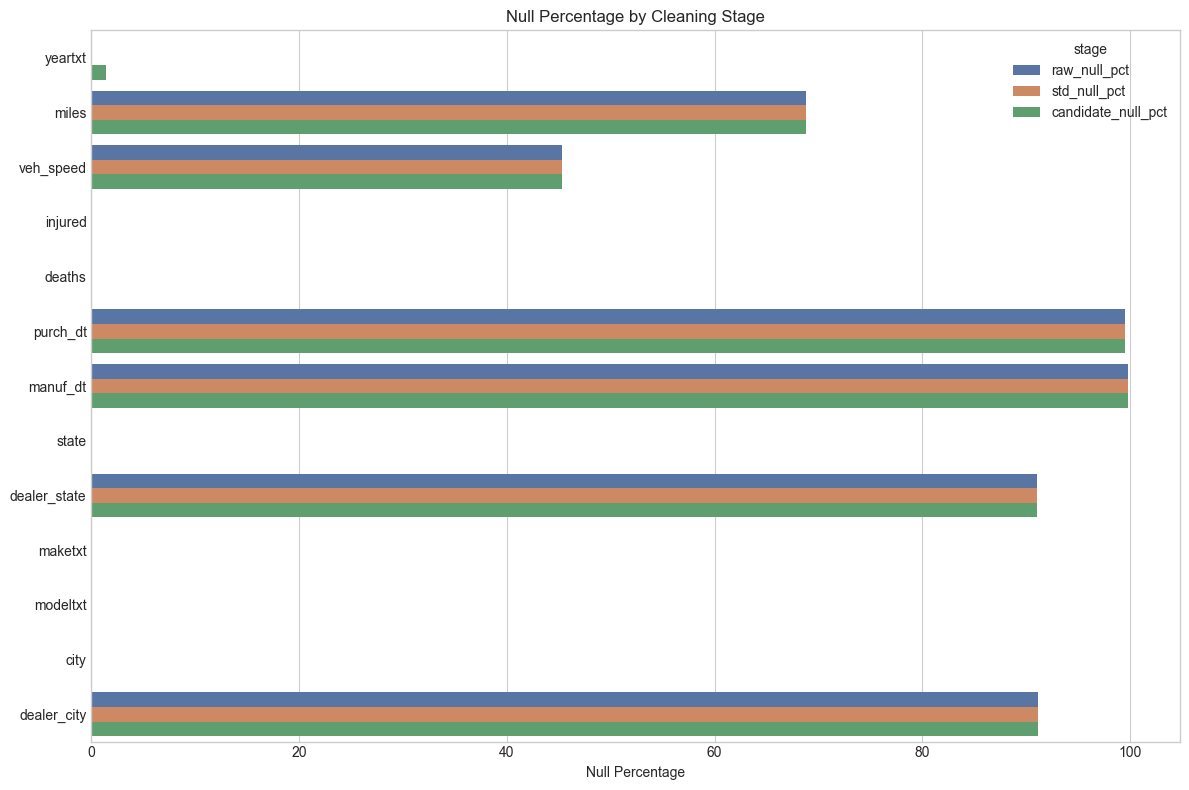

In [20]:
compare_cols = [
    'yeartxt',
    'miles',
    'veh_speed',
    'injured',
    'deaths',
    'purch_dt',
    'manuf_dt',
    'state',
    'dealer_state',
    'maketxt',
    'modeltxt',
    'city',
    'dealer_city'
]

null_compare = pd.DataFrame({
    'raw_null_pct': (raw_df[compare_cols].isna().mean() * 100).round(2),
    'std_null_pct': (std_df[compare_cols].isna().mean() * 100).round(2),
    'candidate_null_pct': (candidate_df[compare_cols].isna().mean() * 100).round(2)
}).reset_index().rename(columns={'index': 'column'})

dtype_compare = pd.DataFrame({
    'raw_dtype': raw_df[compare_cols].dtypes.astype('string'),
    'std_dtype': std_df[compare_cols].dtypes.astype('string'),
    'candidate_dtype': candidate_df[compare_cols].dtypes.astype('string')
}).reset_index().rename(columns={'index': 'column'})

checks = pd.DataFrame([
        {'metric': 'rows after candidate cleaning', 'value': len(candidate_df)},
        {'metric': 'columns in candidate frame', 'value': candidate_df.shape[1]},
        {'metric': 'cmplid unique after candidate cleaning', 'value': candidate_df['cmplid'].nunique(dropna=True)},
        {'metric': 'odino unique after candidate cleaning', 'value': candidate_df['odino'].nunique(dropna=True)},
        {'metric': 'full-row duplicates after candidate cleaning', 'value': int(candidate_df.duplicated().sum())}
])

print("Null percentages by layer: ")
display(null_compare.sort_values('candidate_null_pct', ascending=False))

print("\nData type by layer: ")
display(dtype_compare)

print("\nGeneral checks after cleaning: ")
display(checks)

plot_df = null_compare.melt(id_vars='column', var_name='stage', value_name='null_pct')

plt.figure(figsize=(12, 8))
sns.barplot(data=plot_df, x='null_pct', y='column', hue='stage')
plt.title("Null Percentage by Cleaning Stage")
plt.xlabel("Null Percentage")
plt.ylabel("")
plt.tight_layout()
plt.show()

### 7.2 Raw Versus Candidate Review

Produces views of the flagged "bad" values so we can both inspect if they truly are bad by hand and see if the candidate cleaning changes we've made have sensibly corrected those that aren't going to be dropped. This will be the final sanity check.

In [21]:
review_cols = [
    'cmplid',
    'odino',
    'prod_type',
    'maketxt',
    'modeltxt',
    'yeartxt',
    'state',
    'dealer_state',
    'vin',
    'faildate',
    'datea',
    'ldate',
    'miles',
    'veh_speed',
    'injured',
    'deaths',
    'cdescr'
]

print("Chronology rows to review:")
display(compare_view(flag_df['flag_date_order_bad'], review_cols, n=10))

print("\nBad state rows to review:")
display(compare_view(flag_df['flag_state_bad'] | flag_df['flag_dealer_state_bad'], review_cols, n=10))

print("\nModel year rows to review:")
display(compare_view(flag_df['flag_year_unknown'] | flag_df['flag_year_out_of_range'], review_cols, n=10))

print("\nSpeed and miles rows to review:")
display(compare_view(flag_df['flag_speed_999'] | flag_df['flag_speed_high'] | flag_df['flag_miles_high'], review_cols, n=10))

print("\nVIN rows to review:")
display(compare_view(flag_df['flag_vin_len_bad'], review_cols, n=10))

Chronology rows to review:


,raw_cmplid,raw_odino,raw_prod_type,raw_maketxt,raw_modeltxt,raw_yeartxt,raw_state,raw_dealer_state,raw_vin,raw_faildate,raw_datea,raw_ldate,raw_miles,raw_veh_speed,raw_injured,raw_deaths,raw_cdescr,std_cmplid,std_odino,std_prod_type,std_maketxt,std_modeltxt,std_yeartxt,std_state,std_dealer_state,std_vin,std_faildate,std_datea,std_ldate,std_miles,std_veh_speed,std_injured,std_deaths,std_cdescr,cand_cmplid,cand_odino,cand_prod_type,cand_maketxt,cand_modeltxt,cand_yeartxt,cand_state,cand_dealer_state,cand_vin,cand_faildate,cand_datea,cand_ldate,cand_miles,cand_veh_speed,cand_injured,cand_deaths,cand_cdescr
99459,1732880,11400347,V,HONDA,CR-V,2018,FL,<NA>,2HKRW2H57JH,2021-03-12,2021-03-11,2021-03-11,3000,40,0,0,MANY TIMES I START AND DRIVE THE CAR AND THE YELLOW WARNING LIGHTS STAY ON AND AND ALSO THE RED LIGHT BRAKE KEEP BLI...,1732880,11400347,V,HONDA,CR-V,2018,FL,<NA>,2HKRW2H57JH,2021-03-12,2021-03-11,2021-03-11,3000,40,0,0,MANY TIMES I START AND DRIVE THE CAR AND THE YELLOW WARNING LIGHTS STAY ON AND AND ALSO THE RED LIGHT BRAKE KEEP BLI...,1732880,11400347,V,HONDA,CR-V,2018,FL,<NA>,2HKRW2H57JH,2021-03-12,2021-03-11,2021-03-11,3000,40,0,0,MANY TIMES I START AND DRIVE THE CAR AND THE YELLOW WARNING LIGHTS STAY ON AND AND ALSO THE RED LIGHT BRAKE KEEP BLI...
99460,1732881,11400347,V,HONDA,CR-V,2018,FL,<NA>,2HKRW2H57JH,2021-03-12,2021-03-11,2021-03-11,3000,40,0,0,MANY TIMES I START AND DRIVE THE CAR AND THE YELLOW WARNING LIGHTS STAY ON AND AND ALSO THE RED LIGHT BRAKE KEEP BLI...,1732881,11400347,V,HONDA,CR-V,2018,FL,<NA>,2HKRW2H57JH,2021-03-12,2021-03-11,2021-03-11,3000,40,0,0,MANY TIMES I START AND DRIVE THE CAR AND THE YELLOW WARNING LIGHTS STAY ON AND AND ALSO THE RED LIGHT BRAKE KEEP BLI...,1732881,11400347,V,HONDA,CR-V,2018,FL,<NA>,2HKRW2H57JH,2021-03-12,2021-03-11,2021-03-11,3000,40,0,0,MANY TIMES I START AND DRIVE THE CAR AND THE YELLOW WARNING LIGHTS STAY ON AND AND ALSO THE RED LIGHT BRAKE KEEP BLI...
111120,1744541,11414591,V,FORD,MUSTANG,2018,TX,<NA>,1FATP8UH8J5,2021-06-13,2021-04-30,2021-04-30,54000,72,0,0,DRIVER AND PASSENGER DOOR UNLATCHES AT HIGHWAY SPEEDS. I HAVE OWNED THIS VEHICLE FOR 10 MONTHS AND THIS HAS HAPPENE...,1744541,11414591,V,FORD,MUSTANG,2018,TX,<NA>,1FATP8UH8J5,2021-06-13,2021-04-30,2021-04-30,54000,72,0,0,DRIVER AND PASSENGER DOOR UNLATCHES AT HIGHWAY SPEEDS. I HAVE OWNED THIS VEHICLE FOR 10 MONTHS AND THIS HAS HAPPENE...,1744541,11414591,V,FORD,MUSTANG,2018,TX,<NA>,1FATP8UH8J5,2021-06-13,2021-04-30,2021-04-30,54000,72,0,0,DRIVER AND PASSENGER DOOR UNLATCHES AT HIGHWAY SPEEDS. I HAVE OWNED THIS VEHICLE FOR 10 MONTHS AND THIS HAS HAPPENE...
146957,1780378,11441772,V,JEEP,WRANGLER,2014,SC,<NA>,1C4BJWEG5EL,2021-11-27,2021-11-26,2021-11-26,<NA>,25,0,0,Oil Filter assembly (FCA Pentastar 3.6L) started leaking oil and poured out over the back of the engine and got on t...,1780378,11441772,V,JEEP,WRANGLER,2014,SC,<NA>,1C4BJWEG5EL,2021-11-27,2021-11-26,2021-11-26,<NA>,25,0,0,Oil Filter assembly (FCA Pentastar 3.6L) started leaking oil and poured out over the back of the engine and got on t...,1780378,11441772,V,JEEP,WRANGLER,2014,SC,<NA>,1C4BJWEG5EL,2021-11-27,2021-11-26,2021-11-26,<NA>,25,0,0,Oil Filter assembly (FCA Pentastar 3.6L) started leaking oil and poured out over the back of the engine and got on t...
163450,1796871,11453329,V,HONDA,ACCORD,2019,PR,<NA>,1HGCV1F38KA,2022-02-22,2022-02-21,2022-02-21,<NA>,<NA>,0,0,Tachometer issues.,1796871,11453329,V,HONDA,ACCORD,2019,PR,<NA>,1HGCV1F38KA,2022-02-22,2022-02-21,2022-02-21,<NA>,<NA>,0,0,Tachometer issues.,1796871,11453329,V,HONDA,ACCORD,2019,PR,<NA>,1HGCV1F38KA,2022-02-22,2022-02-21,2022-02-21,<NA>,<NA>,0,0,Tachometer issues.
323898,1957396,11564954,V,CHEVROLET,COLORADO,2018,TX,<NA>,1GCGSCEN8J1,2024-01-24,2024-01-11,2024-01-11,<NA>,<NA>,0,0,"Truck bought in United States for use in US. All dash displays ( child or person in back seat or passenger seat, and...",1957396,11564954,V,CHEVROLET,COLORADO,2018,TX,<NA>,1GCGSCEN8J1,2024-01-24,2024-01-11,2024-01


Bad state rows to review:


,raw_cmplid,raw_odino,raw_prod_type,raw_maketxt,raw_modeltxt,raw_yeartxt,raw_state,raw_dealer_state,raw_vin,raw_faildate,raw_datea,raw_ldate,raw_miles,raw_veh_speed,raw_injured,raw_deaths,raw_cdescr,std_cmplid,std_odino,std_prod_type,std_maketxt,std_modeltxt,std_yeartxt,std_state,std_dealer_state,std_vin,std_faildate,std_datea,std_ldate,std_miles,std_veh_speed,std_injured,std_deaths,std_cdescr,cand_cmplid,cand_odino,cand_prod_type,cand_maketxt,cand_modeltxt,cand_yeartxt,cand_state,cand_dealer_state,cand_vin,cand_faildate,cand_datea,cand_ldate,cand_miles,cand_veh_speed,cand_injured,cand_deaths,cand_cdescr
7295,1640716,11301858,V,SUBARU,IMPREZA,2009,NN,<NA>,JF1GE76679G,2019-10-26,2020-01-25,2020-01-25,10000,0,0,0,HAD A CLUTCH REPAIR DONE ON CAR AFTER THE REPAIR WAS FINISHED THE MECHANIC NOTED THAT THE FIREWALL ON CAR WAS CRACKE...,1640716,11301858,V,SUBARU,IMPREZA,2009,NN,<NA>,JF1GE76679G,2019-10-26,2020-01-25,2020-01-25,10000,0,0,0,HAD A CLUTCH REPAIR DONE ON CAR AFTER THE REPAIR WAS FINISHED THE MECHANIC NOTED THAT THE FIREWALL ON CAR WAS CRACKE...,1640716,11301858,V,SUBARU,IMPREZA,2009,<NA>,<NA>,JF1GE76679G,2019-10-26,2020-01-25,2020-01-25,10000,0,0,0,HAD A CLUTCH REPAIR DONE ON CAR AFTER THE REPAIR WAS FINISHED THE MECHANIC NOTED THAT THE FIREWALL ON CAR WAS CRACKE...
34915,1668336,11328216,V,HONDA,CRF1000,2019,00,<NA>,JH2SD0470KK,2020-05-29,2020-06-10,2020-06-10,7000,50,0,0,ON GOING FUEL TANK CONTAMINATION CAUSING G ENGINE TO QUITE. ALREADY HAD TANK AND PUMP REPLACED O WARRANTY STILL HAV...,1668336,11328216,V,HONDA,CRF1000,2019,00,<NA>,JH2SD0470KK,2020-05-29,2020-06-10,2020-06-10,7000,50,0,0,ON GOING FUEL TANK CONTAMINATION CAUSING G ENGINE TO QUITE. ALREADY HAD TANK AND PUMP REPLACED O WARRANTY STILL HAV...,1668336,11328216,V,HONDA,CRF1000,2019,<NA>,<NA>,JH2SD0470KK,2020-05-29,2020-06-10,2020-06-10,7000,50,0,0,ON GOING FUEL TANK CONTAMINATION CAUSING G ENGINE TO QUITE. ALREADY HAD TANK AND PUMP REPLACED O WARRANTY STILL HAV...
58081,1691502,11354334,V,INFINITI,FX35,2006,00,<NA>,JNRAS08U96X,2020-01-01,2020-09-11,2020-09-11,<NA>,<NA>,0,0,.,1691502,11354334,V,INFINITI,FX35,2006,00,<NA>,JNRAS08U96X,2020-01-01,2020-09-11,2020-09-11,<NA>,<NA>,0,0,.,1691502,11354334,V,INFINITI,FX35,2006,<NA>,<NA>,JNRAS08U96X,2020-01-01,2020-09-11,2020-09-11,<NA>,<NA>,0,0,.
58082,1691503,11354334,E,AIRBAG,SWITCH,9999,00,<NA>,<NA>,2020-01-01,2020-09-11,2020-09-11,<NA>,<NA>,0,0,.,1691503,11354334,E,AIRBAG,SWITCH,9999,00,<NA>,<NA>,2020-01-01,2020-09-11,2020-09-11,<NA>,<NA>,0,0,.,1691503,11354334,E,AIRBAG,SWITCH,<NA>,<NA>,<NA>,<NA>,2020-01-01,2020-09-11,2020-09-11,<NA>,<NA>,0,0,.
68554,1701975,11366216,V,BUICK,CENTURY,1995,00,<NA>,<NA>,1996-07-05,2020-10-24,2020-10-24,<NA>,<NA>,0,0,WATCHED ALOT OF CAR RACES ON TV AND NASCAR RACES ARE ONE OF THOSE RACES WHERE DRIVERS DO CAR ACCIDENTS ON PURPOSE SO...,1701975,11366216,V,BUICK,CENTURY,1995,00,<NA>,<NA>,1996-07-05,2020-10-24,2020-10-24,<NA>,<NA>,0,0,WATCHED ALOT OF CAR RACES ON TV AND NASCAR RACES ARE ONE OF THOSE RACES WHERE DRIVERS DO CAR ACCIDENTS ON PURPOSE SO...,1701975,11366216,V,BUICK,CENTURY,1995,<NA>,<NA>,<NA>,1996-07-05,2020-10-24,2020-10-24,<NA>,<NA>,0,0,WATCHED ALOT OF CAR RACES ON TV AND NASCAR RACES ARE ONE OF THOSE RACES WHERE DRIVERS DO CAR ACCIDENTS ON PURPOSE SO...
68555,1701976,11366216,T,BIG O ARAPAHOE,LT24575R16,9999,00,<NA>,<NA>,1996-07-05,2020-10-24,2020-10-24,<NA>,<NA>,0,0,WATCHED ALOT OF CAR RACES ON TV AND NASCAR RACES ARE ONE OF THOSE RACES WHERE DRIVERS DO CAR ACCIDENTS ON PURPOSE SO...,1701976,11366216,T,BIG O ARAPAHOE,LT24575R16,9999,00,<NA>,<NA>,1996-07-05,2020-10-24,2020-10-24,<NA>,<NA>,0,0,WATCHED ALOT OF CAR RACES ON TV AND NASCAR RACES ARE ONE OF THOSE RACES WHERE DRIVERS DO CAR ACCIDENTS ON PURPOSE SO...,1701976,11366216,T,BIG O ARAPAHOE,LT24575R16,<NA>,<NA>,<NA>,<NA>,1996-07-05,2020-10-24,2020-10-24,<NA>,<NA>,0,0,WATCHED ALOT OF CAR RACES ON TV AND NASCAR RACES ARE ONE OF THOSE RACES WHERE DRIVERS DO CAR ACCIDENTS ON PURPOSE SO...
70188,1703609,11372543,E,BMW,821103939


Model year rows to review:


,raw_cmplid,raw_odino,raw_prod_type,raw_maketxt,raw_modeltxt,raw_yeartxt,raw_state,raw_dealer_state,raw_vin,raw_faildate,raw_datea,raw_ldate,raw_miles,raw_veh_speed,raw_injured,raw_deaths,raw_cdescr,std_cmplid,std_odino,std_prod_type,std_maketxt,std_modeltxt,std_yeartxt,std_state,std_dealer_state,std_vin,std_faildate,std_datea,std_ldate,std_miles,std_veh_speed,std_injured,std_deaths,std_cdescr,cand_cmplid,cand_odino,cand_prod_type,cand_maketxt,cand_modeltxt,cand_yeartxt,cand_state,cand_dealer_state,cand_vin,cand_faildate,cand_datea,cand_ldate,cand_miles,cand_veh_speed,cand_injured,cand_deaths,cand_cdescr
427,1633848,11296686,C,BRITAX,B-SAFE ULTRA,9999,MI,<NA>,<NA>,2020-01-02,2020-01-02,2020-01-02,<NA>,<NA>,0,0,"THE HARNESS STRAPS ON THE CHILD RESTRAINT ARE TWO DIFFERENT LENGTHS (APPROXIMATELY 2-3"" DIFFERENCE), CAUSING THE HAR...",1633848,11296686,C,BRITAX,B-SAFE ULTRA,9999,MI,<NA>,<NA>,2020-01-02,2020-01-02,2020-01-02,<NA>,<NA>,0,0,"THE HARNESS STRAPS ON THE CHILD RESTRAINT ARE TWO DIFFERENT LENGTHS (APPROXIMATELY 2-3"" DIFFERENCE), CAUSING THE HAR...",1633848,11296686,C,BRITAX,B-SAFE ULTRA,<NA>,MI,<NA>,<NA>,2020-01-02,2020-01-02,2020-01-02,<NA>,<NA>,0,0,"THE HARNESS STRAPS ON THE CHILD RESTRAINT ARE TWO DIFFERENT LENGTHS (APPROXIMATELY 2-3"" DIFFERENCE), CAUSING THE HAR..."
566,1633987,11296791,E,NISSAN,999R5-AR000,9999,WI,<NA>,<NA>,2019-12-12,2020-01-03,2020-01-03,<NA>,<NA>,0,0,I WAS DRIVING HOME FROM WORK ABOUT 07:30AM CT. I WAS ON THE INTERSTATE AND HEAR A VERY LOUD BANG AND HEAR GLASS. I...,1633987,11296791,E,NISSAN,999R5-AR000,9999,WI,<NA>,<NA>,2019-12-12,2020-01-03,2020-01-03,<NA>,<NA>,0,0,I WAS DRIVING HOME FROM WORK ABOUT 07:30AM CT. I WAS ON THE INTERSTATE AND HEAR A VERY LOUD BANG AND HEAR GLASS. I...,1633987,11296791,E,NISSAN,999R5-AR000,<NA>,WI,<NA>,<NA>,2019-12-12,2020-01-03,2020-01-03,<NA>,<NA>,0,0,I WAS DRIVING HOME FROM WORK ABOUT 07:30AM CT. I WAS ON THE INTERSTATE AND HEAR A VERY LOUD BANG AND HEAR GLASS. I...
569,1633990,11296795,C,GRACO,CARGO,9999,WA,<NA>,<NA>,2020-01-02,2020-01-03,2020-01-03,<NA>,<NA>,0,0,"NEW WA STATE BOOSTER SEAT LAWS REQUIRE YOUTH UP TO 4'9"" TO RIDE IN A BOOSTER SEAT. WE PURCHASED A SEAT FOR OUR MID S...",1633990,11296795,C,GRACO,CARGO,9999,WA,<NA>,<NA>,2020-01-02,2020-01-03,2020-01-03,<NA>,<NA>,0,0,"NEW WA STATE BOOSTER SEAT LAWS REQUIRE YOUTH UP TO 4'9"" TO RIDE IN A BOOSTER SEAT. WE PURCHASED A SEAT FOR OUR MID S...",1633990,11296795,C,GRACO,CARGO,<NA>,WA,<NA>,<NA>,2020-01-02,2020-01-03,2020-01-03,<NA>,<NA>,0,0,"NEW WA STATE BOOSTER SEAT LAWS REQUIRE YOUTH UP TO 4'9"" TO RIDE IN A BOOSTER SEAT. WE PURCHASED A SEAT FOR OUR MID S..."
2214,1635635,11298031,T,COOPER,EVOLUTION TOUR,9999,VA,<NA>,<NA>,2020-01-05,2020-01-08,2020-01-08,<NA>,<NA>,0,0,PURCHASED 4 COOPER EVOLUTION TOUR ALL SEASON TIRES (225 50 17 94V). DOT U940 1LT 4119 IN NOVEMBER 2019. TIRES DO N...,1635635,11298031,T,COOPER,EVOLUTION TOUR,9999,VA,<NA>,<NA>,2020-01-05,2020-01-08,2020-01-08,<NA>,<NA>,0,0,PURCHASED 4 COOPER EVOLUTION TOUR ALL SEASON TIRES (225 50 17 94V). DOT U940 1LT 4119 IN NOVEMBER 2019. TIRES DO N...,1635635,11298031,T,COOPER,EVOLUTION TOUR,<NA>,VA,<NA>,<NA>,2020-01-05,2020-01-08,2020-01-08,<NA>,<NA>,0,0,PURCHASED 4 COOPER EVOLUTION TOUR ALL SEASON TIRES (225 50 17 94V). DOT U940 1LT 4119 IN NOVEMBER 2019. TIRES DO N...
2257,1635678,11298057,E,CARDONE,REAR BRAKE CALIPER,9999,IL,<NA>,<NA>,2019-09-29,2020-01-09,2020-01-09,<NA>,<NA>,0,0,I REPAIRED MY DAUGHTER JEEP WITH A REPLACEMENT CALIPER/BRACKET ASSEMBLY FROM A LOCAL PARTS STORE. THE REPLACEMENT CA...,1635678,11298057,E,CARDONE,REAR BRAKE CALIPER,9999,IL,<NA>,<NA>,2019-09-29,2020-01-09,2020-01-09,<NA>,<NA>,0,0,I REPAIRED MY DAUGHTER JEEP WITH A REPLACEMENT CALIPER/BRACKET ASSEMBLY FROM A LOCAL PARTS STORE. THE REPLACEMENT CA...,1635678,11298057,E,CARDONE,REAR BRAKE CALIPER,<NA>,IL,<NA>,<NA>,2019-09-29,2020-01-09,2020-01-09,<NA>,<NA>,0,0,I REPAIRED MY DAUGHTER JEEP WITH A REPLACEMENT CALIPER/BRACKET ASSEMBLY FROM A LOCAL PARTS STORE. THE REPLACEMENT CA...



Speed and miles rows to review:


,raw_cmplid,raw_odino,raw_prod_type,raw_maketxt,raw_modeltxt,raw_yeartxt,raw_state,raw_dealer_state,raw_vin,raw_faildate,raw_datea,raw_ldate,raw_miles,raw_veh_speed,raw_injured,raw_deaths,raw_cdescr,std_cmplid,std_odino,std_prod_type,std_maketxt,std_modeltxt,std_yeartxt,std_state,std_dealer_state,std_vin,std_faildate,std_datea,std_ldate,std_miles,std_veh_speed,std_injured,std_deaths,std_cdescr,cand_cmplid,cand_odino,cand_prod_type,cand_maketxt,cand_modeltxt,cand_yeartxt,cand_state,cand_dealer_state,cand_vin,cand_faildate,cand_datea,cand_ldate,cand_miles,cand_veh_speed,cand_injured,cand_deaths,cand_cdescr
734,1634155,11296922,V,TOYOTA,TUNDRA,2015,FL,<NA>,5TFGY5F18FX,2020-01-03,2020-01-03,2020-01-03,580000,45,0,0,"WHEN USING LEFT TURN SIGNAL, HEADLIGHTS AND TAIL LIGHTS SHUT OFF FOR A FEW SECONDS. THIS HAPPENS IN MOTION AND WHEN ...",1634155,11296922,V,TOYOTA,TUNDRA,2015,FL,<NA>,5TFGY5F18FX,2020-01-03,2020-01-03,2020-01-03,580000,45,0,0,"WHEN USING LEFT TURN SIGNAL, HEADLIGHTS AND TAIL LIGHTS SHUT OFF FOR A FEW SECONDS. THIS HAPPENS IN MOTION AND WHEN ...",1634155,11296922,V,TOYOTA,TUNDRA,2015,FL,<NA>,5TFGY5F18FX,2020-01-03,2020-01-03,2020-01-03,580000,45,0,0,"WHEN USING LEFT TURN SIGNAL, HEADLIGHTS AND TAIL LIGHTS SHUT OFF FOR A FEW SECONDS. THIS HAPPENS IN MOTION AND WHEN ..."
735,1634156,11296922,V,TOYOTA,TUNDRA,2015,FL,<NA>,5TFGY5F18FX,2020-01-03,2020-01-03,2020-01-03,580000,45,0,0,"WHEN USING LEFT TURN SIGNAL, HEADLIGHTS AND TAIL LIGHTS SHUT OFF FOR A FEW SECONDS. THIS HAPPENS IN MOTION AND WHEN ...",1634156,11296922,V,TOYOTA,TUNDRA,2015,FL,<NA>,5TFGY5F18FX,2020-01-03,2020-01-03,2020-01-03,580000,45,0,0,"WHEN USING LEFT TURN SIGNAL, HEADLIGHTS AND TAIL LIGHTS SHUT OFF FOR A FEW SECONDS. THIS HAPPENS IN MOTION AND WHEN ...",1634156,11296922,V,TOYOTA,TUNDRA,2015,FL,<NA>,5TFGY5F18FX,2020-01-03,2020-01-03,2020-01-03,580000,45,0,0,"WHEN USING LEFT TURN SIGNAL, HEADLIGHTS AND TAIL LIGHTS SHUT OFF FOR A FEW SECONDS. THIS HAPPENS IN MOTION AND WHEN ..."
911,1634332,11297052,V,LEXUS,NX,2015,VA,<NA>,JTJBARBZ1F2,2020-01-03,2020-01-04,2020-01-04,46000,354,2,0,"BAD HEAD ON COLLISION AND MY AIRBAGS DIDN'T DEPLOY, SEATBELT DIDN'T KEEP ME FROM POUNDING MY FACE INTO WHEEL MY CAR ...",1634332,11297052,V,LEXUS,NX,2015,VA,<NA>,JTJBARBZ1F2,2020-01-03,2020-01-04,2020-01-04,46000,354,2,0,"BAD HEAD ON COLLISION AND MY AIRBAGS DIDN'T DEPLOY, SEATBELT DIDN'T KEEP ME FROM POUNDING MY FACE INTO WHEEL MY CAR ...",1634332,11297052,V,LEXUS,NX,2015,VA,<NA>,JTJBARBZ1F2,2020-01-03,2020-01-04,2020-01-04,46000,354,2,0,"BAD HEAD ON COLLISION AND MY AIRBAGS DIDN'T DEPLOY, SEATBELT DIDN'T KEEP ME FROM POUNDING MY FACE INTO WHEEL MY CAR ..."
912,1634333,11297052,V,LEXUS,NX,2015,VA,<NA>,JTJBARBZ1F2,2020-01-03,2020-01-04,2020-01-04,46000,354,2,0,"BAD HEAD ON COLLISION AND MY AIRBAGS DIDN'T DEPLOY, SEATBELT DIDN'T KEEP ME FROM POUNDING MY FACE INTO WHEEL MY CAR ...",1634333,11297052,V,LEXUS,NX,2015,VA,<NA>,JTJBARBZ1F2,2020-01-03,2020-01-04,2020-01-04,46000,354,2,0,"BAD HEAD ON COLLISION AND MY AIRBAGS DIDN'T DEPLOY, SEATBELT DIDN'T KEEP ME FROM POUNDING MY FACE INTO WHEEL MY CAR ...",1634333,11297052,V,LEXUS,NX,2015,VA,<NA>,JTJBARBZ1F2,2020-01-03,2020-01-04,2020-01-04,46000,354,2,0,"BAD HEAD ON COLLISION AND MY AIRBAGS DIDN'T DEPLOY, SEATBELT DIDN'T KEEP ME FROM POUNDING MY FACE INTO WHEEL MY CAR ..."
938,1634359,11297073,V,KIA,SOUL,2018,FL,<NA>,KNDJN2A24J7,2020-01-03,2020-01-04,2020-01-04,1440000,10,0,0,MY CHECK ENGINE LIGHT CAME ON AND EVERY TIME I TOOK IT IN FOR SERVICE I WAS TOLD I USED BAD GAS AND TO CHANGE THE GA...,1634359,11297073,V,KIA,SOUL,2018,FL,<NA>,KNDJN2A24J7,2020-01-03,2020-01-04,2020-01-04,1440000,10,0,0,MY CHECK ENGINE LIGHT CAME ON AND EVERY TIME I TOOK IT IN FOR SERVICE I WAS TOLD I USED BAD GAS AND TO CHANGE THE GA...,1634359,11297073,V,KIA,SOUL,2018,FL,<NA>,KNDJN2A24J7,2020-01-03,2020-01-04,2020-01-04,1440000,10,0,0,MY CHECK ENGINE LIGHT CAME ON AND EVERY TIME I TOOK IT IN FOR SERVICE I WAS TOLD I USED BAD GAS AND TO CHANGE THE GA...
939,1634360


VIN rows to review:


,raw_cmplid,raw_odino,raw_prod_type,raw_maketxt,raw_modeltxt,raw_yeartxt,raw_state,raw_dealer_state,raw_vin,raw_faildate,raw_datea,raw_ldate,raw_miles,raw_veh_speed,raw_injured,raw_deaths,raw_cdescr,std_cmplid,std_odino,std_prod_type,std_maketxt,std_modeltxt,std_yeartxt,std_state,std_dealer_state,std_vin,std_faildate,std_datea,std_ldate,std_miles,std_veh_speed,std_injured,std_deaths,std_cdescr,cand_cmplid,cand_odino,cand_prod_type,cand_maketxt,cand_modeltxt,cand_yeartxt,cand_state,cand_dealer_state,cand_vin,cand_faildate,cand_datea,cand_ldate,cand_miles,cand_veh_speed,cand_injured,cand_deaths,cand_cdescr
49162,1682583,11343662,V,KEYSTONE,BULLET,2020,ID,ID,5549043,2020-06-15,2020-08-06,2020-08-06,0,<NA>,0,0,TL* THE CONTACT OWNS A 2020 KEYSTONE BULLET CROSSFIRE TRAVEL TRAILER. THE CONTACT STATED THAT THE DEMOTIC WATER HEAT...,1682583,11343662,V,KEYSTONE,BULLET,2020,ID,ID,5549043,2020-06-15,2020-08-06,2020-08-06,0,<NA>,0,0,TL* THE CONTACT OWNS A 2020 KEYSTONE BULLET CROSSFIRE TRAVEL TRAILER. THE CONTACT STATED THAT THE DEMOTIC WATER HEAT...,1682583,11343662,V,KEYSTONE,BULLET,2020,ID,ID,5549043,2020-06-15,2020-08-06,2020-08-06,0,<NA>,0,0,TL* THE CONTACT OWNS A 2020 KEYSTONE BULLET CROSSFIRE TRAVEL TRAILER. THE CONTACT STATED THAT THE DEMOTIC WATER HEAT...
49163,1682584,11343662,V,KEYSTONE,BULLET,2020,ID,ID,5549043,2020-06-15,2020-08-06,2020-08-06,0,<NA>,0,0,TL* THE CONTACT OWNS A 2020 KEYSTONE BULLET CROSSFIRE TRAVEL TRAILER. THE CONTACT STATED THAT THE DEMOTIC WATER HEAT...,1682584,11343662,V,KEYSTONE,BULLET,2020,ID,ID,5549043,2020-06-15,2020-08-06,2020-08-06,0,<NA>,0,0,TL* THE CONTACT OWNS A 2020 KEYSTONE BULLET CROSSFIRE TRAVEL TRAILER. THE CONTACT STATED THAT THE DEMOTIC WATER HEAT...,1682584,11343662,V,KEYSTONE,BULLET,2020,ID,ID,5549043,2020-06-15,2020-08-06,2020-08-06,0,<NA>,0,0,TL* THE CONTACT OWNS A 2020 KEYSTONE BULLET CROSSFIRE TRAVEL TRAILER. THE CONTACT STATED THAT THE DEMOTIC WATER HEAT...
64935,1698356,11363400,V,FORD,ESCAPE,2015,TX,<NA>,1FMCU,2020-09-26,2020-10-08,2020-10-08,51900,70,0,0,"I HAVE A 2015 FORD ESCAPE THAT HAS LESS THEN 51,000 MILES. FORD'S POWERTRAIN WARRANTY IS 5 YRS OR 60,000 MILES AND I...",1698356,11363400,V,FORD,ESCAPE,2015,TX,<NA>,1FMCU,2020-09-26,2020-10-08,2020-10-08,51900,70,0,0,"I HAVE A 2015 FORD ESCAPE THAT HAS LESS THEN 51,000 MILES. FORD'S POWERTRAIN WARRANTY IS 5 YRS OR 60,000 MILES AND I...",1698356,11363400,V,FORD,ESCAPE,2015,TX,<NA>,1FMCU,2020-09-26,2020-10-08,2020-10-08,51900,70,0,0,"I HAVE A 2015 FORD ESCAPE THAT HAS LESS THEN 51,000 MILES. FORD'S POWERTRAIN WARRANTY IS 5 YRS OR 60,000 MILES AND I..."
114361,1747782,11417484,V,HONDA,ACCORD,2018,NC,NC,1HGCV2F65J,2021-02-01,2021-05-17,2021-05-17,15000,55,0,0,"THE CONTACT OWNS A 2018 HONDA ACCORD. THE CONTACT WAS DRIVING AT 55-65 MPH, WHEN THE COLLISION MITIGATION BRAKING SY...",1747782,11417484,V,HONDA,ACCORD,2018,NC,NC,1HGCV2F65J,2021-02-01,2021-05-17,2021-05-17,15000,55,0,0,"THE CONTACT OWNS A 2018 HONDA ACCORD. THE CONTACT WAS DRIVING AT 55-65 MPH, WHEN THE COLLISION MITIGATION BRAKING SY...",1747782,11417484,V,HONDA,ACCORD,2018,NC,NC,1HGCV2F65J,2021-02-01,2021-05-17,2021-05-17,15000,55,0,0,"THE CONTACT OWNS A 2018 HONDA ACCORD. THE CONTACT WAS DRIVING AT 55-65 MPH, WHEN THE COLLISION MITIGATION BRAKING SY..."
115053,1748474,11418041,V,DODGE,RAM 2500,2012,OH,OH,3C6TD5DT1C,2021-05-18,2021-05-21,2021-05-21,170000,3,0,0,The contact owns a 2012 Ram 2500. The contact stated that after making the third right turn while driving approximat...,1748474,11418041,V,DODGE,RAM 2500,2012,OH,OH,3C6TD5DT1C,2021-05-18,2021-05-21,2021-05-21,170000,3,0,0,The contact owns a 2012 Ram 2500. The contact stated that after making the third right turn while driving approximat...,1748474,11418041,V,DODGE,RAM 2500,2012,OH,OH,3C6TD5DT1C,2021-05-18,2021-05-21,2021-05-21,170000,3,0,0,The contact owns a 2012 Ram 2500. The contact stated that after making the third right turn while driving approximat...
115608,1749029,11418453,V,FORD,FUSION,2011,SC,<NA>,3FADP0L34B,

## 8. Vehicle-Ready Outputs

The main candidate cleaning rules are in place, so next up is previewing the focused layer of vehicle product type responses only as that will be used for the first and maybe all structured modeling work. This way we can confirm whether the rules behave as expected when the modeling cohort is restricted to vehicles only.

In [22]:
vehicle_mask = candidate_df['prod_type'].eq('V').fillna(False)
vehicle_candidate = candidate_df.loc[vehicle_mask].copy()

vehicle_ready = pd.DataFrame([
    {'metric': 'vehicle rows', 'value': len(vehicle_candidate)},
    {'metric': 'vehicle row share pct', 'value': round(float(len(vehicle_candidate) / len(candidate_df) * 100), 2)},
    {'metric': 'vehicle unique makes', 'value': vehicle_candidate['maketxt'].nunique(dropna=True)},
    {'metric': 'vehicle unique models', 'value': vehicle_candidate['modeltxt'].nunique(dropna=True)}
])

vehicle_core = pd.DataFrame({
    'vehicle_non_null_pct': (vehicle_candidate[[
            'maketxt',
            'modeltxt',
            'yeartxt',
            'state',
            'miles',
            'veh_speed',
            'injured',
            'deaths',
            'cdescr'
        ]].notna().mean() * 100
    ).round(2)
}).reset_index().rename(columns={'index': 'column'})

vehicle_flags = pd.DataFrame([
    {
        'flag': col,
        'vehicle_row_pct': round(float(flag_df.loc[vehicle_candidate.index, col].fillna(False).sum() / len(vehicle_candidate) * 100), 4)
    }
    for col in flag_df.columns
]).sort_values('vehicle_row_pct', ascending=False)

print("General vehicle cohort overview:")
display(vehicle_ready)

print("\nCore vehicle features coverage:")
display(vehicle_core)

print("\nPercent of vehicle cohort rows flagged bad or suspicious:")
display(vehicle_flags)

General vehicle cohort overview:


,metric,value
0,vehicle rows,537936.00
1,vehicle row share pct,98.66
2,vehicle unique makes,397.00
3,vehicle unique models,2718.00



Core vehicle features coverage:


,column,vehicle_non_null_pct
0,maketxt,100.00
1,modeltxt,100.00
2,yeartxt,99.90
3,state,99.99
4,miles,31.64
5,veh_speed,55.42
6,injured,100.00
7,deaths,100.00
8,cdescr,99.99



Percent of vehicle cohort rows flagged bad or suspicious:


,flag,vehicle_row_pct
16,flag_fail_pre_model,0.1628
17,flag_fail_pre_model_far,0.1379
2,flag_year_out_of_range,0.0982
1,flag_year_unknown,0.0982
15,flag_fail_old_new_vehicle,0.0890
5,flag_miles_high,0.0647
10,flag_vin_len_bad,0.0608
4,flag_speed_high,0.0565
8,flag_state_bad,0.0080
3,flag_speed_999,0.0035


### 8.1 Structured Model Table Preview

Maps specific cleaning decisions to the modeling task it is appropriate for and gives a quick audit.

In [23]:
severity_policy = pd.DataFrame([
    {
        'decision': 'unit of analysis',
        'value': 'one complaint case per odino'
    },
    {
        'decision': 'primary severity label',
        'value': "deaths > 0 or injured > 0 or fire == 'Y' or crash == 'Y'"
    },
    {
        'decision': 'broader sensitivity label',
        'value': "primary label plus medical_attn == 'Y' or vehicles_towed_yn == 'Y'"
    },
    {
        'decision': 'excluded from first severity baseline',
        'value': 'injured, deaths, fire, crash, medical_attn, vehicles_towed_yn, datea'
    }
])

component_policy = pd.DataFrame([
    {
        'decision': 'unit of analysis',
        'value': 'vehicle complaint-component row'
    },
    {
        'decision': 'raw target source',
        'value': 'compdesc'
    },
    {
        'decision': 'first target cleanup step',
        'value': 'standardize raw component labels and then build logical component groups'
    },
    {
        'decision': 'first baseline target form',
        'value': 'cleaned component group after grouping work is finished'
    }
])

multi_case_counts = vehicle_candidate.groupby('odino').size()
multi_case_odino = multi_case_counts[multi_case_counts > 1].index
multi_case_df = vehicle_candidate.loc[vehicle_candidate['odino'].isin(multi_case_odino)].copy()
case_conflict = pd.DataFrame([
    {
        'column': col,
        'multi_case_conflicts': int(multi_case_df.groupby('odino')[col].nunique(dropna=True).gt(1).sum())
    }
    for col in [
        'maketxt',
        'modeltxt',
        'yeartxt',
        'state',
        'faildate',
        'ldate',
        'datea',
        'miles',
        'veh_speed',
        'injured',
        'deaths',
        'fire',
        'crash'
    ]
]).sort_values(['multi_case_conflicts', 'column'], ascending=[False, True])

severity_case_df = (
    vehicle_candidate.sort_values(['odino', 'cmplid'])
    .groupby('odino', dropna=False)
    .agg(
        row_count=('cmplid', 'size'),
        component_count=('compdesc', lambda s: s.astype('string').dropna().nunique()),
        component_list=('compdesc', lambda s: ' | '.join(sorted(set(s.dropna().astype(str)))[:4])),
        maketxt=('maketxt', 'first'),
        modeltxt=('modeltxt', 'first'),
        yeartxt=('yeartxt', 'first'),
        state=('state', 'first'),
        ldate=('ldate', 'first'),
        faildate=('faildate', 'first'),
        lag_days_safe=('lag_days_safe', 'first'),
        miles=('miles', 'first'),
        veh_speed=('veh_speed', 'first'),
        miles_missing_flag=('miles_missing_flag', 'max'),
        veh_speed_missing_flag=('veh_speed_missing_flag', 'max'),
        faildate_untrusted_flag=('faildate_untrusted_flag', 'max'),
        severity_primary_flag=('severity_primary_row_flag', 'max'),
        severity_broad_flag=('severity_broad_row_flag', 'max')
    ).reset_index()
)

component_model_df = vehicle_candidate.loc[vehicle_candidate['compdesc'].notna(), [
    'cmplid',
    'odino',
    'ldate',
    'maketxt',
    'modeltxt',
    'yeartxt',
    'state',
    'miles',
    'veh_speed',
    'miles_missing_flag',
    'veh_speed_missing_flag',
    'faildate_untrusted_flag',
    'lag_days_safe',
    'compdesc'
]].rename(columns={'compdesc': 'component_raw'}).copy()

severity_summary = pd.DataFrame([
    {
        'metric': 'severity case rows',
        'value': len(severity_case_df)
    },
    {
        'metric': 'cases with >1 component row',
        'value': int((severity_case_df['row_count'] > 1).sum())
    },
    {
        'metric': 'primary high-risk case rate pct',
        'value': round(float(severity_case_df['severity_primary_flag'].mean() * 100), 2)
    },
    {
        'metric': 'broad high-risk case rate pct',
        'value': round(float(severity_case_df['severity_broad_flag'].mean() * 100), 2)
    },
    {
        'metric': 'cases with untrusted faildate pct',
        'value': round(float(severity_case_df['faildate_untrusted_flag'].mean() * 100), 2)
    }
])

component_summary = pd.DataFrame([
    {
        'metric': 'component-model rows',
        'value': len(component_model_df)
    },
    {
        'metric': 'unique complaint cases in component table',
        'value': component_model_df['odino'].nunique(dropna=True)
    },
    {
        'metric': 'unique raw component labels',
        'value': component_model_df['component_raw'].nunique(dropna=True)
    },
    {
        'metric': 'rows with untrusted faildate pct',
        'value': round(float(component_model_df['faildate_untrusted_flag'].mean() * 100), 2)
    }
])

component_top = (
    component_model_df['component_raw']
    .value_counts()
    .head(15)
    .rename_axis('component_raw')
    .reset_index(name='rows')
)

severity_preview = severity_case_df.loc[:,[
    'odino',
    'row_count',
    'component_count',
    'component_list',
    'maketxt',
    'modeltxt',
    'yeartxt',
    'ldate',
    'lag_days_safe',
    'faildate_untrusted_flag',
    'severity_primary_flag',
    'severity_broad_flag'
]].head(10)

print("Severity model policy:")
display(severity_policy)

print("\nComponent model policy:")
display(component_policy)

print("\nODINO collapse consistency check for multi-row cases:")
display(case_conflict)

print("\nSeverity case-level table summary:")
display(severity_summary)

print("\nSample severity case rows:")
display(severity_preview)

print("\nComponent row-level table summary:")
display(component_summary)

print("\nTop raw component labels before grouping:")
display(component_top)

Severity model policy:


,decision,value
0,unit of analysis,one complaint case per odino
1,primary severity label,deaths > 0 or injured > 0 or fire == 'Y' or crash == 'Y'
2,broader sensitivity label,primary label plus medical_attn == 'Y' or vehicles_towed_yn == 'Y'
3,excluded from first severity baseline,"injured, deaths, fire, crash, medical_attn, vehicles_towed_yn, datea"



Component model policy:


,decision,value
0,unit of analysis,vehicle complaint-component row
1,raw target source,compdesc
2,first target cleanup step,standardize raw component labels and then build logical component groups
3,first baseline target form,cleaned component group after grouping work is finished



ODINO collapse consistency check for multi-row cases:


...

,odino,row_count,component_count,component_list,maketxt,modeltxt,yeartxt,ldate,lag_days_safe,faildate_untrusted_flag,severity_primary_flag,severity_broad_flag
0,10816121,1,1,AIR BAGS,PONTIAC,VIBE,2007,2020-10-05,104,0,0,0
1,11289434,1,1,STEERING,HONDA,CR-V,2019,2020-01-02,178,0,0,0
2,11289436,1,1,VEHICLE SPEED CONTROL,HYUNDAI,SONATA,2018,2020-01-02,58,0,1,1
3,11290552,1,1,ENGINE,DODGE,DURANGO,2011,2020-01-02,311,0,1,1
4,11292384,3,3,ELECTRICAL SYSTEM | ENGINE | SERVICE BRAKES,HONDA,ACCORD,2018,2020-01-01,11,0,0,0
5,11292385,1,1,ELECTRICAL SYSTEM,FORD,EXPLORER,2020,2020-01-01,6,0,0,0
6,11292386,3,3,ELECTRONIC STABILITY CONTROL (ESC) | SERVICE BRAKES | VEHICLE SPEED CONTROL,CHEVROLET,VOLT,2017,2020-01-01,173,0,0,0
7,11292387,1,1,POWER TRAIN,TOYOTA,CAMRY,2014,2020-01-01,1279,0,0,0
8,11292388,1,1,STEERING,CHEVROLET,MALIBU,2007,2020-01-01,9,0,0,0
9,11292389,3,3,SERVICE BRAKES | STEERING | SUSPENSION,HYUNDAI,AZERA,2015,2020-01-01,0,0,0,0



Component row-level table summary:


,metric,value
0,component-model rows,537935.00
1,unique complaint cases in component table,375936.00
2,unique raw component labels,693.00
3,rows with untrusted faildate pct,0.16



Top raw component labels before grouping:


,component_raw,rows
0,ENGINE,80260
1,ELECTRICAL SYSTEM,65037
2,UNKNOWN OR OTHER,53457
3,POWER TRAIN,52171
4,STEERING,35328
5,SERVICE BRAKES,31878
6,FUEL/PROPULSION SYSTEM,24503
7,AIR BAGS,22818
8,STRUCTURE:BODY,15245
9,SUSPENSION,14042


## 9. Component Target Design

The component task needs a cleaned and grouped target, not the raw component strings as is. So we need to build and check the grouped component design before it moves into the pipeline.

In [24]:
comp_target = component_model_df.copy()

comp_target['component_raw_std'] = (
    comp_target['component_raw']
    .astype('string')
    .str.upper()
    .str.replace(r'\s*;\s*', ':', regex=True)
    .str.replace(r'\s*:\s*', ':', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

comp_target['component_parent'] = (
    comp_target['component_raw_std']
    .str.split(':')
    .str[0]
    .str.strip()
)

drop_child_parents = {
    'CHEST CLIP, BUCKLE, HARNESS',
    'CARRY HANDLE, SHELL, BASE',
    'CHILD SEAT',
    'TETHER, LOWER ANCHOR (ON CAR SEAT OR VEHICLE)',
    'I SUSPECT THE CAR SEAT IS COUNTERFEIT',
    'INSERT, PADDING'
}


def map_component_group(label):
    parent = label.split(':', 1)[0].strip()

    if label in {'UNKNOWN OR OTHER', 'OTHER/I AM NOT SURE'}:
        return 'UNKNOWN OR OTHER'

    if parent in {'COMMUNICATION', 'COMMUNICATIONS'}:
        return 'COMMUNICATION'

    if parent in {'ENGINE', 'ENGINE AND ENGINE COOLING'}:
        return 'ENGINE / COOLING'

    if parent in {'VISIBILITY', 'VISIBILITY/WIPER'}:
        return 'VISIBILITY / WIPER'

    if parent in {
        'FUEL/PROPULSION SYSTEM',
        'FUEL SYSTEM, GASOLINE',
        'FUEL SYSTEM, DIESEL',
        'FUEL SYSTEM, OTHER',
        'HYBRID PROPULSION SYSTEM'
    }:
        return 'FUEL / PROPULSION'

    if parent in {
        'SERVICE BRAKES',
        'SERVICE BRAKES, HYDRAULIC',
        'SERVICE BRAKES, AIR',
        'SERVICE BRAKES, ELECTRIC'
    }:
        return 'SERVICE BRAKES'

    return parent


comp_target['component_group'] = comp_target['component_raw_std'].map(map_component_group)

comp_target['drop_reason'] = pd.NA

comp_target.loc[
    comp_target['component_parent'].isin(drop_child_parents),
    'drop_reason'
] = 'DROP_CHILD_RESTRAINT'

comp_target.loc[
    comp_target['component_group'].isin({'EQUIPMENT', 'EQUIPMENT ADAPTIVE/MOBILITY'}),
    'drop_reason'
] = 'DROP_EQUIPMENT'

comp_target.loc[
    comp_target['component_group'].eq('UNKNOWN OR OTHER'),
    'drop_reason'
] = 'DROP_UNKNOWN_OTHER'

group_counts = (
    comp_target.loc[comp_target['drop_reason'].isna(), 'component_group']
    .value_counts()
)

comp_target['component_group_rows'] = comp_target['component_group'].map(group_counts)

comp_target.loc[
    comp_target['drop_reason'].isna() & comp_target['component_group_rows'].lt(250),
    'drop_reason'
] = 'DROP_RARE_GROUP'

comp_target['keep_for_component_model'] = comp_target['drop_reason'].isna()

component_map_final = (
    comp_target.groupby(
        [
            'component_raw_std',
            'component_parent',
            'component_group',
            'component_group_rows',
            'drop_reason',
            'keep_for_component_model'
        ],
        dropna=False
    )
    .size()
    .reset_index(name='rows')
    .sort_values(
        ['keep_for_component_model', 'rows', 'component_group', 'component_raw_std'],
        ascending=[False, False, True, True]
    )
    .reset_index(drop=True)
)

print("Component group and subgroup breakdown w/ decision:")
display(component_map_final.head(50))


# Summary of what was kept and what was dropped
component_group_summary = (
    comp_target.loc[comp_target['keep_for_component_model']]
    .groupby('component_group', dropna=False)
    .size()
    .reset_index(name='rows')
    .sort_values('rows', ascending=False)
    .reset_index(drop=True)
)

component_drop_summary = (
    comp_target.assign(
        drop_reason=comp_target['drop_reason'].fillna('KEEP')
    )
    .groupby('drop_reason', dropna=False)
    .size()
    .reset_index(name='rows')
    .sort_values('rows', ascending=False)
    .reset_index(drop=True)
)

print("\nSummary of kept groupings:")
display(component_group_summary)

print("\nSummary of dropped components:")
display(component_drop_summary)


# Check to see amount of remaining complaints are only about a single component group
component_model_rows = comp_target.loc[comp_target['keep_for_component_model']].copy()
case_group_counts = component_model_rows.groupby('odino')['component_group'].nunique()

single_case_ids = case_group_counts.loc[case_group_counts.eq(1)].index
multi_case_ids = case_group_counts.loc[case_group_counts.gt(1)].index

component_single_targets = (
    component_model_rows.loc[
        component_model_rows['odino'].isin(single_case_ids),
        ['odino', 'component_group']
    ]
    .drop_duplicates()
    .sort_values(['odino', 'component_group'])
    .groupby('odino', sort=True)
    .first()
    .reset_index()
)

component_single_case_summary = pd.DataFrame(
    [
        {
            'metric': 'final_component_groups',
            'value': int(component_group_summary['component_group'].nunique())
        },
        {
            'metric': 'kept_component_rows',
            'value': int(len(component_model_rows))
        },
        {
            'metric': 'kept_complaint_cases',
            'value': int(component_model_rows['odino'].nunique())
        },
        {
            'metric': 'single_label_cases',
            'value': int(len(single_case_ids))
        },
        {
            'metric': 'multi_label_cases',
            'value': int(len(multi_case_ids))
        },
        {
            'metric': 'single_label_case_share_pct',
            'value': round(float(len(single_case_ids) / component_model_rows['odino'].nunique() * 100), 2)
        }
    ]
)

print("\nShare of complaints that are single component and multi component:")
display(component_single_case_summary)

print("\nSample of some single component rows:")
display(component_single_targets.head(10))

Component group and subgroup breakdown w/ decision:


,component_raw_std,component_parent,component_group,component_group_rows,drop_reason,keep_for_component_model,rows
0,ENGINE,ENGINE,ENGINE / COOLING,90468.0,NaN,True,80260
1,ELECTRICAL SYSTEM,ELECTRICAL SYSTEM,ELECTRICAL SYSTEM,68233.0,NaN,True,65037
2,POWER TRAIN,POWER TRAIN,POWER TRAIN,54222.0,NaN,True,52171
3,STEERING,STEERING,STEERING,35905.0,NaN,True,35328
4,SERVICE BRAKES,SERVICE BRAKES,SERVICE BRAKES,38453.0,NaN,True,31878
5,FUEL/PROPULSION SYSTEM,FUEL/PROPULSION SYSTEM,FUEL / PROPULSION,31418.0,NaN,True,24503
6,AIR BAGS,AIR BAGS,AIR BAGS,23379.0,NaN,True,22818
7,STRUCTURE:BODY,STRUCTURE,STRUCTURE,20718.0,NaN,True,15245
8,SUSPENSION,SUSPENSION,SUSPENSION,14481.0,NaN,True,14042
9,VEHICLE SPEED CONTROL,VEHICLE SPEED CONTROL,VEHICLE SPEED CONTROL,14563.0,NaN,True,13889



Summary of kept groupings:


,component_group,rows
0,ENGINE / COOLING,90468
1,ELECTRICAL SYSTEM,68233
2,POWER TRAIN,54222
3,SERVICE BRAKES,38453
4,STEERING,35905
5,FUEL / PROPULSION,31418
6,FORWARD COLLISION AVOIDANCE,24292
7,AIR BAGS,23379
8,STRUCTURE,20718
9,VISIBILITY / WIPER,15203



Summary of dropped components:


,drop_reason,rows
0,KEEP,481819
1,DROP_UNKNOWN_OTHER,53539
2,DROP_EQUIPMENT,1554
3,DROP_RARE_GROUP,702
4,DROP_CHILD_RESTRAINT,321



Share of complaints that are single component and multi component:


,metric,value
0,final_component_groups,22.00
1,kept_component_rows,481819.00
2,kept_complaint_cases,346274.00
3,single_label_cases,252122.00
4,multi_label_cases,94152.00
5,single_label_case_share_pct,72.81



Sample of some single component rows:


,odino,component_group
0,10816121,AIR BAGS
1,11289434,STEERING
2,11289436,VEHICLE SPEED CONTROL
3,11290552,ENGINE / COOLING
4,11292385,ELECTRICAL SYSTEM
5,11292387,POWER TRAIN
6,11292388,STEERING
7,11292390,ENGINE / COOLING
8,11292391,ENGINE / COOLING
9,11292393,FUEL / PROPULSION


## 10. Decision Queue

Not every question needs to be solved in the same pass and we can lock in most of this logic if it gives us a strong baseline cleaning to work with. Decisions that only affect specific project tasks can be done just for that project's preprocessing step.

In [25]:
decision_queue = pd.DataFrame([
    {
        'topic': 'component grouping',
        'current_position': 'component model table is ready but the cleaned component target is not finalized',
        'next_check': 'review unique raw component labels and build the first component group map'
    },
    {
        'topic': 'severity baseline feature list',
        'current_position': 'severity unit, label, and excluded leakage-prone fields are now settled',
        'next_check': 'freeze the first feature list before moving the cleaner into src'
    },
    {
        'topic': 'component baseline feature list',
        'current_position': 'component table is row-ready and severity-adjacent fields are excluded from the first pass',
        'next_check': 'confirm whether any dealer fields or date-derived fields belong in the first component baseline'
    },
    {
        'topic': 'src pipeline handoff',
        'current_position': 'notebook logic is close to final for the shared cleaning layer',
        'next_check': 'port the settled rules and first-pass model tables into a reproducible src module'
    }
])

display(decision_queue)

,topic,current_position,next_check
0,component grouping,component model table is ready but the cleaned component target is not finalized,review unique raw component labels and build the first component group map
1,severity baseline feature list,"severity unit, label, and excluded leakage-prone fields are now settled",freeze the first feature list before moving the cleaner into src
2,component baseline feature list,component table is row-ready and severity-adjacent fields are excluded from the first pass,confirm whether any dealer fields or date-derived fields belong in the first component baseline
3,src pipeline handoff,notebook logic is close to final for the shared cleaning layer,port the settled rules and first-pass model tables into a reproducible src module


## 11. Scratchpad

Keep one-off testing here to prevent disruption of the cleaning flow.

In [ ]:
# Example checks
# compare_view(flag_df['flag_speed_high'], review_cols, n=25)
# candidate_df.loc[candidate_df['prod_type'] == 'V', ['maketxt', 'modeltxt', 'compdesc']].head(20)
# candidate_df.groupby('prod_type').size().sort_values(ascending=False)
# candidate_df.loc[flag_df['flag_miles_high'], ['maketxt', 'modeltxt', 'miles', 'cdescr']].head(20)
